# EDA 03 (Bureau Balance)

## Resumen

`bureau_balance` es el histórico mensual del buró: 27.299.925 filas y solo tres columnas, un estado por crédito y mes, sin ninguna variable financiera. No trae identificador de cliente ni objetivo propio, así que para cruzarlo con el default hay que pasar por `bureau` y agregar dos veces, primero de los meses al crédito y después de los créditos al cliente.

La cobertura condiciona todo lo demás y tiene dos caras. Solo el 29,99% de los clientes de train tiene histórico mensual, muy por debajo del 85,69% que tiene historial en `bureau`, así que esto es información sobre un tercio de la cartera. Pero cuando la hay es completa: el 99,78% de esos clientes la tiene para todos sus créditos, y eso es lo que permite leer un cliente sin mora como cliente sin mora, y no como cliente del que solo veo una parte. Los 203 que quedan sí son distintos, con un 22,17% de default frente al 8,11%, así que esa lectura se sostiene porque son el 0,22%, no porque se parezcan al resto.

Lo que aporta esta tabla, y no aporta ninguna otra fuente del buró, es **cuándo** ocurrió la mora. Tener DPD en los últimos 6 meses de la ventana observada de un crédito da +4,92pp de default (12,30% frente a 7,38%), y la recencia traza un gradiente monótono que va del 6,62% cuando el último DPD fue hace más de dos años hasta el 13,29% si fue en los últimos tres meses. Y no duplica lo que ya sabía: frente a la mora que reporta `bureau` la V de Cramér es 0,3945, el histórico rescata 16.000 clientes con DPD que aquella no marcaba y `bureau` aporta otros 7.653 que el histórico no ve. Por eso codifico la mora como la unión de las dos fuentes, que rinde +2,73pp sobre 88.419 clientes, más delta y más cobertura que cualquiera por separado.

Conservo el núcleo de mora reciente, que son la flag y la recencia continua medida hasta el fin de la ventana de cada crédito y repartida en tramos, no como valor continuo directo. Con ella entran la mora en tres niveles en lugar de binaria, el fallido como flag propia (+2,94pp), la intensidad de meses en mora sobre meses reportados con un mínimo de 6 meses reportados, y la trayectoria, que separa a quien se mantiene en mora (11,94%) de quien empeora (11,16%) y de quien se recupera. La persistencia no es la recencia disfrazada: aporta 3,17pp entre los clientes sin mora reciente, que son justo a los que la recencia no llega.

Los descartes tienen distinto grado de firmeza y conviene no mezclarlos. La longitud del histórico es la señal más alta en crudo (0,1502) y aun así se cae, porque mide la profundidad de historial que ya cuenta `bureau` con una correlación de −0,7451, y ese descarte no depende del objetivo. Lo mismo la recencia contada hasta la solicitud, que pierde contra la relativa y correlaciona 0,8229 con ella. Por señal, y por tanto de forma provisional hasta reconfirmarlo sobre el conjunto de entrenamiento, caen la severidad como escala (dentro de los clientes que ya tienen mora no discrimina, 0,0065 con p=0,40), el conteo de créditos como continua y la flag de recuperación, porque quien sale de la mora vuelve al riesgo de base.

Tres límites para leer todo lo anterior. La señal es fuerte pero estrecha, ya que la flag principal marca a 14.288 clientes, el 4,65% del conjunto. Las tasas de default están calculadas sobre el conjunto completo, así que la lista definitiva se fija sobre el de entrenamiento. Y la recencia comparte alrededor de 0,30 con el score de buró de la solicitud, de modo que tendrá que demostrar aportación por encima de él antes de entrar.

### Índice

- 1. Carga
- 2. Distribución variable marco (meses de histórico por crédito) + cruce con `TARGET`
- 3. Verificación dtypes / Clasificación variables
- 4. Análisis distribuciones variables
- 5. Análisis Missings
- 6. Análisis Correlaciones
- 7. Análisis Temporal
- 8. Análisis de Outliers
- 9. Estrategia de agregación (nivel cliente)
- 10. Validación por bloques (TARGET real)
- 11. Conclusiones y features candidatas

In [1]:
import sys
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, norm, spearmanr, pearsonr, chi2_contingency
from scipy.stats.contingency import association

sys.path.insert(0, str(Path.cwd().parent))
from src.data.loader import load_table, verify_dtypes
from src.features.eval import EvaluadorSenal

COLOR_NODEF, COLOR_DEF = "steelblue", "crimson"

### 1. Carga

In [2]:
bb = load_table("bureau_balance")
bureau = load_table("bureau")
train = load_table("application_train")

bb.info(memory_usage="deep")
bb.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27299925 entries, 0 to 27299924
Data columns (total 3 columns):
 #   Column          Dtype   
---  ------          -----   
 0   SK_ID_BUREAU    uint32  
 1   MONTHS_BALANCE  int8    
 2   STATUS          category
dtypes: category(1), int8(1), uint32(1)
memory usage: 156.2 MB


,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C


In [3]:
# la unicidad del par (SK_ID_BUREAU, MONTHS_BALANCE) implica la unicidad de la fila completa
n_dup_row = int(bb.duplicated().sum())
assert not bb.duplicated(subset=["SK_ID_BUREAU", "MONTHS_BALANCE"]).any(), "par crédito-mes no único"
print(f"filas: {len(bb):,} | SK_ID_BUREAU únicos: {bb['SK_ID_BUREAU'].nunique():,}")
print(f"Integridad: par (SK_ID_BUREAU, MONTHS_BALANCE) único | duplicados de fila completa: {n_dup_row}")
print(f"nulos literales por columna: {bb.isnull().sum().to_dict()}")  # 0 en las 3: la ausencia es STATUS='X'

filas: 27,299,925 | SK_ID_BUREAU únicos: 817,395
Integridad: par (SK_ID_BUREAU, MONTHS_BALANCE) único | duplicados de fila completa: 0
nulos literales por columna: {'SK_ID_BUREAU': 0, 'MONTHS_BALANCE': 0, 'STATUS': 0}


In [4]:
# cobertura triple: bureau_balance - bureau - train (SK_ID_BUREAU es PK en bureau)
bb_ids = bb["SK_ID_BUREAU"].unique()
en_bureau = bureau["SK_ID_BUREAU"].isin(bb_ids)            # créditos de bureau que tienen histórico
bureau_train = bureau[bureau["SK_ID_CURR"].isin(train["SK_ID_CURR"])]
map_bc = bureau_train.loc[bureau_train["SK_ID_BUREAU"].isin(bb_ids), ["SK_ID_BUREAU", "SK_ID_CURR"]]

n_cred, n_train = len(bb_ids), train["SK_ID_CURR"].nunique()
cli_bureau, cli_hist = bureau_train["SK_ID_CURR"].nunique(), map_bc["SK_ID_CURR"].nunique()

print(f"créditos con histórico: {n_cred:,} | en bureau: {en_bureau.sum():,} | huérfanos: {n_cred - en_bureau.sum():,}")
print(f"créditos de bureau con histórico mensual: {en_bureau.mean() * 100:.2f}%")
print(f"clientes con historial bureau: {cli_bureau:,} ({cli_bureau / n_train * 100:.2f}%)")
print(f"clientes con histórico mensual: {cli_hist:,} ({cli_hist / n_train * 100:.2f}%)")

créditos con histórico: 817,395 | en bureau: 774,354 | huérfanos: 43,041
créditos de bureau con histórico mensual: 45.11%
clientes con historial bureau: 263,491 (85.69%)
clientes con histórico mensual: 92,231 (29.99%)


In [5]:
# ¿la cobertura es del crédito o del cliente? de eso depende que una flag de mora agregada sea interpretable
tiene = bureau_train["SK_ID_BUREAU"].isin(bb_ids)
cob = tiene.groupby(bureau_train["SK_ID_CURR"]).agg(total="size", con="sum")
con_bal = cob[cob["con"] > 0]
completa = con_bal["con"].eq(con_bal["total"])
tgt_cli = train.set_index("SK_ID_CURR")["TARGET"]
print(f"clientes con algún histórico mensual: {len(con_bal):,} | con todos sus créditos cubiertos: "
      f"{int(completa.sum()):,} ({completa.mean() * 100:.2f}%) | con cobertura parcial: {int((~completa).sum())}")
print(f"default con cobertura completa: {tgt_cli.reindex(con_bal.index[completa]).mean() * 100:.2f}%")

# los 203 de cobertura parcial nunca se habían medido, y sin eso la cobertura casi completa
# es media afirmación: no basta con que sean pocos, hay que saber si son distintos
ev_cob = EvaluadorSenal(train, train["TARGET"].values)  # instancia propia, fuera de la familia del ranking
con_hist = train["SK_ID_CURR"].isin(con_bal.index).values
parcial = train["SK_ID_CURR"].isin(con_bal.index[~completa]).values
esp = chi2_contingency(pd.crosstab(parcial[con_hist], train["TARGET"].values[con_hist]))[3]
print(f"frecuencia esperada mínima: {esp.min():.1f} (el z-test de proporciones pide 5 o más)")
ev_cob.evaluar_flags([("cobertura parcial", parcial, con_hist, "clientes con histórico")])

# ¿y depende de algún atributo del crédito? (grupos con menos de 5.000 créditos quedan fuera por muestra)
antig = pd.cut(-bureau_train["DAYS_CREDIT"] / 365.25, [0, 1, 3, 5, 50], labels=["0-1a", "1-3a", "3-5a", "5a+"])
filas = []
for eje, clave in [("CREDIT_ACTIVE", bureau_train["CREDIT_ACTIVE"].astype(str)),
                   ("CREDIT_TYPE", bureau_train["CREDIT_TYPE"].astype(str)),
                   ("antigüedad", antig)]:
    t = tiene.groupby(clave, observed=True).agg(n="size", pct="mean")
    for grupo, r in t[t["n"] >= 5000].iterrows():
        filas.append({"eje": eje, "grupo": grupo, "créditos": int(r["n"]), "% con histórico": round(r["pct"] * 100, 2)})
display(pd.DataFrame(filas))

clientes con algún histórico mensual: 92,231 | con todos sus créditos cubiertos: 92,028 (99.78%) | con cobertura parcial: 203
default con cobertura completa: 8.11%
frecuencia esperada mínima: 16.5 (el z-test de proporciones pide 5 o más)


Variable,Población,Tasa (1),Tasa (0),Delta,z-stat,p-valor
cobertura parcial,clientes con histórico,22.17% (n=203),8.11% (n=92028),+14.06 pp,7.3,2.5825426883516146e-13


,eje,grupo,créditos,% con histórico
0,CREDIT_ACTIVE,Active,541919,35.68
1,CREDIT_ACTIVE,Closed,917733,35.75
2,CREDIT_ACTIVE,Sold,5653,36.39
3,CREDIT_TYPE,Car loan,23757,36.08
4,CREDIT_TYPE,Consumer credit,1069610,35.68
5,CREDIT_TYPE,Credit card,343853,35.42
6,CREDIT_TYPE,Microloan,9005,49.51
7,CREDIT_TYPE,Mortgage,15607,37.18
8,antigüedad,0-1a,279128,36.79
9,antigüedad,1-3a,521761,36.22


La tabla tiene 27.299.925 filas y 3 columnas (156,2 MB tras `reduce_mem_usage`), sin un solo
duplicado de fila ni del par `(SK_ID_BUREAU, MONTHS_BALANCE)`, cada fila es un crédito-mes único,
como esperaba. Hay 817.395 créditos con histórico mensual.

La cobertura es lo primero que me impacta y tiene consecuencias. Solo el **45,11%** de los créditos de `bureau` tiene histórico mensual, y **43.041 `SK_ID_BUREAU`** del balance no existen en `bureau`: son huérfanos que se pierden al cruzar con el `TARGET` (sin `bureau` no hay `SK_ID_CURR`).

A nivel cliente: de los 263.491 clientes de train con historial en `bureau` (85,69%), solo **92.231 (29,99%) tienen histórico mensual**. Es un tercio del dataset, muy por debajo de la cobertura de
`bureau`.

Antes de seguir necesitaba saber de qué tipo es esa cobertura, porque un 45,11% de créditos cubiertos admite dos
lecturas muy distintas: que de cada cliente vea unos créditos sí y otros no, o que el buró reporte o no reporte el
historial completo del cliente. La diferencia no es menor, porque en el primer caso cualquier medida de mora agregada
sería ambigua, ya que un cliente sin mora podría tenerla en los créditos que no veo.

Es lo segundo, y de forma casi absoluta: de los 92.231 clientes con histórico mensual, 92.028 (99,78%) lo tienen para
todos sus créditos de bureau, y solo 203 tienen cobertura parcial. Esos 203 no son un residuo inocuo: su default es del 22,17% frente al 8,11% de
los de cobertura completa, +14,06pp con z=7,3 y p=2,6e-13. Son tan pocos, el 0,22% de los clientes con histórico, que
no mueven ninguna decisión, pero dejan claro de qué depende la tranquilidad: cuando el buró reporta solo una parte de
los créditos de un cliente, ese cliente es sistemáticamente más arriesgado, así que leer un cliente sin mora como
cliente sin mora se sostiene porque son poquísimos, no porque se parezcan al resto. Y la cobertura tampoco depende de cómo sea el
crédito: 35,68% en los activos, 35,75% en los cerrados y 36,39% en los vendidos, entre 35,42% y 37,18% por tipo de
producto (con Microloan como única excepción, 49,51% sobre 9.005 créditos), y 36,79% en el primer año frente a 32,42%
a más de cinco. La cobertura es una propiedad del cliente, no del crédito ni del producto.

Esto me anticipa que `HAS_BUREAU_BALANCE` medirá disponibilidad de reporte del buró, pero no necesariamente riesgo, y
me deja el terreno limpio para la agregación: cuando mida mora a nivel cliente estaré viendo su historial entero o no
estaré viendo nada, sin medias tintas que confundan ausencia de mora con ausencia de crédito observado.

### 2. Distribución variable marco (meses de histórico por crédito) + cruce con `TARGET`

count    817395.00
mean         33.40
std          25.79
min           1.00
50%          26.00
75%          48.00
90%          77.00
95%          90.00
99%          97.00
max          97.00
dtype: float64


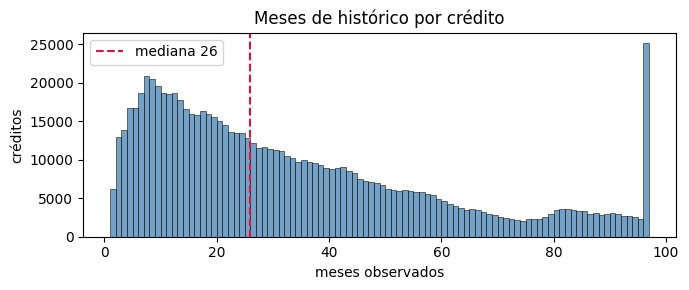

In [6]:
# BB_MONTHS_COUNT: meses de histórico observados por crédito
meses_credito = bb.groupby("SK_ID_BUREAU").size()
print(meses_credito.describe(percentiles=[.5, .75, .9, .95, .99]).round(2))

fig, ax = plt.subplots(figsize=(7, 3))
sns.histplot(meses_credito, binwidth=1, color=COLOR_NODEF, ax=ax)
ax.axvline(meses_credito.median(), color=COLOR_DEF, ls="--", label=f"mediana {meses_credito.median():.0f}")
ax.set(title="Meses de histórico por crédito", xlabel="meses observados", ylabel="créditos")
ax.legend(); plt.tight_layout(); plt.show()

                    n   tasa
sin histórico  215280   8.04
1-12m           11866  11.85
13-24m          14911  10.20
25-48m          27573   7.91
49m+            37881   6.34


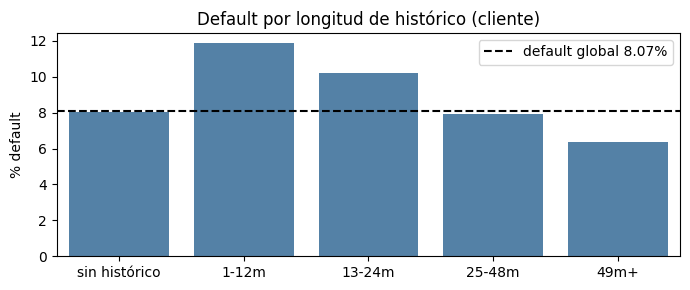

In [7]:
# histórico máximo por cliente (BB_MONTHS_MAX); 0 = cliente sin histórico mensual
mc = meses_credito.rename("meses").reset_index().merge(map_bc, on="SK_ID_BUREAU")
bb_months_max = mc.groupby("SK_ID_CURR")["meses"].max().reindex(train["SK_ID_CURR"], fill_value=0).values
target = train["TARGET"].values

bins, labels = [-1, 0, 12, 24, 48, np.inf], ["sin histórico", "1-12m", "13-24m", "25-48m", "49m+"]
binned = pd.cut(bb_months_max, bins=bins, labels=labels)
tab = pd.Series(target).groupby(binned, observed=False).agg(n="size", tasa="mean")
tab["tasa"] = (tab["tasa"] * 100).round(2)
print(tab)

fig, ax = plt.subplots(figsize=(7, 3))
sns.barplot(x=tab.index, y=tab["tasa"], color=COLOR_NODEF, ax=ax)
ax.axhline(target.mean() * 100, color="black", ls="--", label=f"default global {target.mean()*100:.2f}%")
ax.set(title="Default por longitud de histórico (cliente)", xlabel="", ylabel="% default")
ax.legend(); plt.tight_layout(); plt.show()

In [8]:
# effect size de la longitud de histórico (solo clientes con histórico)
has = bb_months_max > 0
x0, x1 = bb_months_max[has & (target == 0)], bb_months_max[has & (target == 1)]
u, p_mw = mannwhitneyu(x0, x1)
r_rb = abs(2 * u / (len(x0) * len(x1)) - 1)
rho, _ = spearmanr(bb_months_max[has], target[has])
r, _ = pearsonr(bb_months_max[has], target[has])
print(f"BB_MONTHS_MAX (con histórico): rank-biserial={r_rb:.4f} (p={p_mw:.1e}) | Pearson={r:.4f} | Spearman={rho:.4f}")

# presencia: con histórico vs sin histórico (z-test de proporciones + IC 95%)
p1, n1 = target[has].mean(), int(has.sum())
p0, n0 = target[~has].mean(), int((~has).sum())
pp = target.mean()
z = (p1 - p0) / np.sqrt(pp * (1 - pp) * (1 / n1 + 1 / n0))
margin = 1.96 * np.sqrt(p1 * (1 - p1) / n1 + p0 * (1 - p0) / n0)
print(f"con histórico {p1*100:.2f}% (n={n1:,}) vs sin histórico {p0*100:.2f}% (n={n0:,}) | "
      f"delta {(p1-p0)*100:+.2f}pp | z={z:.2f} p={2*norm.sf(abs(z)):.3f} | "
      f"IC95 [{(p1-p0-margin)*100:+.2f}, {(p1-p0+margin)*100:+.2f}]pp")

BB_MONTHS_MAX (con histórico): rank-biserial=0.1502 (p=1.7e-103) | Pearson=-0.0688 | Spearman=-0.0711
con histórico 8.14% (n=92,231) vs sin histórico 8.04% (n=215,280) | delta +0.10pp | z=0.93 p=0.353 | IC95 [-0.11, +0.31]pp


La longitud del histórico mensual por crédito es asimétrica con cola larga: mediana 26 meses, media 33,4, y una acumulación en el tope de 97 meses (unos 8 años, créditos seguidos desde el inicio de la ventana del buró).

La hipótesis que planteé era doble: más meses de histórico implicaría cliente más establecido lo que conllevaba menor riesgo, y quizá la simple presencia de histórico ya discriminaba.

Entre los clientes con histórico, el gradiente de default es monótono decreciente y limpio: de 1 a 12 meses 11,85%, de 13 a 24 10,20%, de 25 a 48 7,91% y de 49 en adelante 6,34% (un factor de 1,9 del extremo corto al largo). Pero la relación no es globalmente monótona: el grupo sin histórico (8,04%, n=215.280) cae en medio, pegado a la base, no en un extremo. El riesgo lo concentran los históricos **cortos**, no la ausencia de histórico.

Lo confirma el z-test de presencia: con histórico 8,14% vs sin histórico 8,04%, un delta de +0,10pp (z=0,93, p=0,353, IC95 [-0,11, +0,31]pp) que no es significativo. Al contrario que en `bureau`, donde no tener historial sí marcaba -2,39pp, aquí la disponibilidad del histórico la decide el buró que reporta, no el riesgo del cliente. Consecuencia: `HAS_BUREAU_BALANCE` será una flag de control cuando agregue a nivel cliente, no un predictor.

El effect size lo remata con un matiz de forma: rank-biserial 0,1502 (moderado) frente a Pearson -0,069 y Spearman -0,071 (bajos). La brecha entre rank-biserial y Pearson indica una relación monótona no lineal, con efecto umbral en los históricos cortos, así que al construir las features conviene binning o transformación, no el valor continuo directo.

Por último, la longitud del histórico mensual mide profundidad de historial crediticio, que es exactamente lo que mide `BUREAU_DAYS_CREDIT_MIN` en `bureau` (la antigüedad del crédito más antiguo), así que es muy probable que sean redundantes. No la descarto aquí: la redundancia se comprueba con las dos ya agregadas a nivel cliente.

### 3. Verificación dtypes / Clasificación variables

In [9]:
display(verify_dtypes("bureau_balance", bb))
# STATUS es la única variable analítica: ordinal de 0 a 5 (tramos de DPD, días de impago), con C y X fuera de escala

,Variable,Tipo Actual,Categoría Esperada,Estado,Detalle
0,SK_ID_BUREAU,uint32,ID,OK,
1,MONTHS_BALANCE,int8,Days/Time,OK,
2,STATUS,category,Categorical,OK,


Los tres dtypes salen OK: `SK_ID_BUREAU` uint32 (identificador), `MONTHS_BALANCE` int8 (temporal, rango [-96, 0]) y `STATUS` category. Ya son óptimos tras `reduce_mem_usage`; no hay nada que recodificar por tipo.

Lo único a retener: `STATUS` es la única variable analítica y no es una categórica plana, sino ordinal (de 0 a 5, tramos de DPD, los días de impago acumulados) con `C` (cerrado) y `X` (sin dato) fuera de escala.

### 4. Análisis distribuciones variables

In [10]:
vc = bb["STATUS"].value_counts()
dist = pd.DataFrame({"n": vc, "%": (vc / len(bb) * 100).round(3)})
display(dist)
dpd = vc[["1", "2", "3", "4", "5"]].sum()
print(f"DPD real (1-5): {dpd:,} ({dpd / len(bb) * 100:.2f}%)")
s = bb["STATUS"].astype("string")
print(f"higiene STATUS: {s.nunique()} niveles vs {s.str.strip().str.upper().nunique()} normalizados")

,n,%
STATUS,,
C,13646993,49.989
0,7499507,27.471
X,5810482,21.284
1,242347,0.888
5,62406,0.229
2,23419,0.086
3,8924,0.033
4,5847,0.021


DPD real (1-5): 342,943 (1.26%)


higiene STATUS: 8 niveles vs 8 normalizados


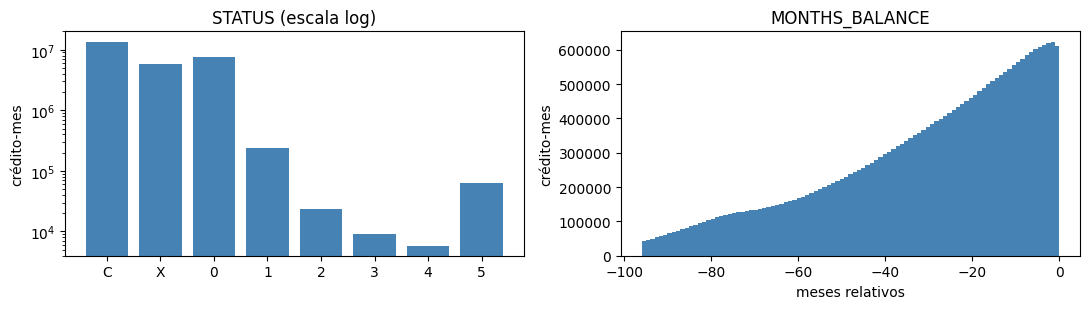

MONTHS_BALANCE: rango [-96, 0], mediana -25


In [11]:
orden = ["C", "X", "0", "1", "2", "3", "4", "5"]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].bar(orden, [vc[k] for k in orden], color=COLOR_NODEF)
ax[0].set_yscale("log")
ax[0].set(title="STATUS (escala log)", ylabel="crédito-mes")
ax[1].hist(bb["MONTHS_BALANCE"], bins=97, color=COLOR_NODEF)
ax[1].set(title="MONTHS_BALANCE", xlabel="meses relativos", ylabel="crédito-mes")
plt.tight_layout(); plt.show()
print(f"MONTHS_BALANCE: rango [{bb['MONTHS_BALANCE'].min()}, {bb['MONTHS_BALANCE'].max()}], mediana {bb['MONTHS_BALANCE'].median():.0f}")

`STATUS`: la distribución muestra que el 77,46% de los crédito-mes están cerrados o al corriente, repartidos entre `C` (49,99%, 13.646.993, crédito saldado) y `0` (27,47%, 7.499.507, activo sin mora), lo cual es coherente con una población que ya ha liquidado buena parte de su historial externo. El tercer bloque, `X` (21,28%, 5.810.482), no es un estado de mora sino ausencia de reporte ese mes, así que lo trato como el eje de missing de esta tabla y lo analizo aparte. La mora real (niveles `1` a `5`) es apenas el 1,26% (342.943) y decae en cascada de casi un orden de magnitud por escalón: `1` con 0,89%, `2` con 0,086%, `3` con 0,033% y `4` con 0,021%, mientras que `5` repunta a 0,229% porque acumula los casos de impago definitivo (fallido). Es la distribución de "masa en cero más cola de eventos raros", exactamente el patrón que observé en la mora de bureau (`CREDIT_DAY_OVERDUE`, `AMT_CREDIT_SUM_OVERDUE`), donde la señal discriminante vivía en la cola y no en el centro, y espero lo mismo aquí. La higiene sale limpia: 8 niveles crudos igual a 8 normalizados, sin variantes por espacios ni caso.

Esta concentración tiene consecuencias que anticipo ya. Como el 98,7% de los crédito-mes (`C`, `X` y `0`) está pegado a la ausencia de mora, cuando agregue a nivel cliente no podré usar un promedio de `STATUS`, porque diluiría los pocos meses en mora hasta el ruido; tendré que subir la cola con el peor estado, una flag de si hubo algún DPD, el conteo de meses en mora y la recencia del último. Y el encoding tendrá que ser tripartito, con la escala ordinal de `0` a `5` para la severidad, `C` como señal propia de crédito saldado y `X` como indicador de missing (no imputado a `0`, que lo confundiría con "activo sin mora"), en vez de un nominal plano que mezcle los tres ejes; lo dejo planteado para la construcción de features. Los niveles severos `3`, `4` y `5` (8.924, 5.847 y 62.406 crédito-mes) son tan escasos que la severidad fina no será fiablemente monótona, así que los trataré agrupados en un "DPD grave", con la misma cautela con la que traté "Bad debt" (n=21) en bureau.

`MONTHS_BALANCE`: su rango va de -96 a 0 con mediana en -25, y el histograma concentra más masa cerca de 0. La forma encaja con lo que esperaría si cada crédito se siguiese hasta el mes de la solicitud: los offsets recientes acumularían casi todos los créditos y los de -90 en adelante solo los de historial más largo. Ese supuesto lo doy por comprobar en el análisis temporal, porque de él depende cómo se lee cualquier medida de recencia. Al ser un índice temporal acotado y no un numérico libre, no espero outliers de dominio que revertir, y la pregunta de fondo, si la mora reciente pesa más que la antigua, la abordo al mirar el eje temporal.

### 5. Análisis Missings

In [12]:
# bureau_balance no tiene NaN literales ya que como missing esta STATUS='X'
tgt = train[["SK_ID_CURR", "TARGET"]]
bb_t = bb.merge(map_bc, on="SK_ID_BUREAU").merge(tgt, on="SK_ID_CURR")
assert not bb_t["TARGET"].isna().any()
print(f"bb_t: {len(bb_t):,} crédito-mes con TARGET | default global {bb_t['TARGET'].mean()*100:.2f}%")

s = bb_t["STATUS"].astype(str)
for lvl in ["C", "X", "0"]:
    m = s == lvl
    print(f"STATUS {lvl}: default {bb_t.loc[m, 'TARGET'].mean()*100:.2f}% (n={int(m.sum()):,})")

bb_t: 14,701,612 crédito-mes con TARGET | default global 6.94%


STATUS C: default 6.39% (n=7,027,575)
STATUS X: default 6.96% (n=2,837,039)


STATUS 0: default 7.59% (n=4,615,684)


MONTHS_BALANCE
60m+      23.97
36-60m    20.01
12-36m    18.60
0-12m     17.77
Name: STATUS, dtype: float64


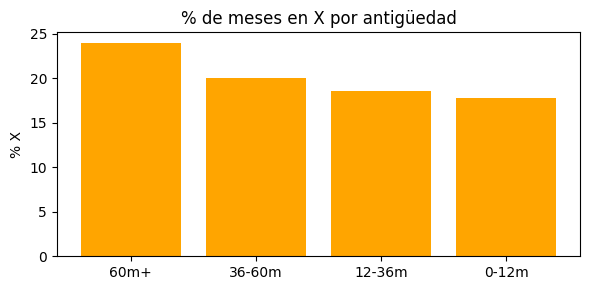

In [13]:
# ¿la ausencia (X) depende del tiempo?
isx = bb_t["STATUS"].astype(str).eq("X")
antig = pd.cut(bb_t["MONTHS_BALANCE"], [-97, -60, -36, -12, 1], labels=["60m+", "36-60m", "12-36m", "0-12m"])
pctx = isx.groupby(antig, observed=True).mean().mul(100).round(2)
print(pctx)

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(pctx.index.astype(str), pctx.values, color="orange")
ax.set(title="% de meses en X por antigüedad", ylabel="% X")
plt.tight_layout(); plt.show()

In [14]:
# ¿X carga señal a nivel cliente o enmascara la mora rara?
s = bb_t["STATUS"].astype(str)
bb_t["isX"], bb_t["isDPD"] = s.eq("X"), s.isin(["1", "2", "3", "4", "5"])

# default de X por recencia (nivel fila)
recbin = pd.cut(bb_t["MONTHS_BALANCE"], [-97, -24, -12, -6, 1], labels=["24m+", "12-24m", "6-12m", "0-6m"])
recX = bb_t.loc[bb_t["isX"]].groupby(recbin, observed=True)["TARGET"].mean().mul(100).round(2)
print("default de X por recencia:", recX.to_dict())

# nivel cliente: % de meses en X vs TARGET, y masking (X en créditos con/sin DPD)
g = bb_t.groupby("SK_ID_CURR")
cli = pd.DataFrame({"tot": g.size(), "nx": g["isX"].sum(), "ndpd": g["isDPD"].sum(), "TARGET": g["TARGET"].first()})
cli["pctX"], cli["has_dpd"] = cli["nx"] / cli["tot"] * 100, cli["ndpd"] > 0
x0, x1 = cli.loc[cli.TARGET == 0, "pctX"], cli.loc[cli.TARGET == 1, "pctX"]
u, pv = mannwhitneyu(x0, x1)
print(f"% meses en X vs TARGET (cliente): rank-biserial={abs(2*u/(len(x0)*len(x1))-1):.4f} (p={pv:.2f})")
print(f"% X medio (cliente) | CON DPD: {cli.loc[cli.has_dpd,'pctX'].mean():.2f}% vs SIN DPD: {cli.loc[~cli.has_dpd,'pctX'].mean():.2f}%")
# a nivel crédito el contraste es más marcado
gc = bb_t.groupby("SK_ID_BUREAU")
cred = pd.DataFrame({"tot": gc.size(), "nx": gc["isX"].sum(), "ndpd": gc["isDPD"].sum()})
cred["pctX"], cred["has_dpd"] = cred["nx"] / cred["tot"] * 100, cred["ndpd"] > 0
print(f"% X medio (crédito) | CON DPD: {cred.loc[cred.has_dpd,'pctX'].mean():.2f}% vs SIN DPD: {cred.loc[~cred.has_dpd,'pctX'].mean():.2f}%")

default de X por recencia: {'24m+': 6.25, '12-24m': 7.37, '6-12m': 7.92, '0-6m': 8.37}


% meses en X vs TARGET (cliente): rank-biserial=0.0085 (p=0.22)
% X medio (cliente) | CON DPD: 15.56% vs SIN DPD: 20.03%


% X medio (crédito) | CON DPD: 8.79% vs SIN DPD: 22.04%


`X` es el eje de missing de esta tabla, porque no hay un solo NaN en toda la tabla: la ausencia se codifica como un estado más. Con 2.837.039 crédito-mes (el 19,30% del histórico enlazado a train, y el 21,28% de la tabla completa), su tasa de default es 6,96%, que queda entre `C` (6,39%, crédito cerrado) y `0` (7,59%, activo al corriente) y muy por debajo de cualquier tramo de mora. Su aparición depende de la antigüedad del mes, del 17,77% en los meses más recientes (0 a 12) al 23,97% en los más antiguos (más de 60), en un crecimiento monótono: es el mismo deterioro de reporte con la antigüedad que observé en bureau, el buró deja de informar el estado de los meses viejos. Por eso lo clasifico como MAR, ya que la ausencia depende de una variable observada (el tiempo), y no como MNAR, porque no es un missing marcado por el riesgo oculto.

Antes de darlo por malo he comprobado que no esté enmascarando la señal de default, que es lo que más me importa preservar. Primero, a nivel cliente el porcentaje de meses en `X` no discrimina el default (rank-biserial 0,0085, p=0,22, con los bins de `X` todos en torno al 8%), así que como agregado es ruido. Segundo, y más decisivo, `X` y la mora están inversamente relacionados: los créditos con algún DPD tienen mucho menos `X` (8,79%) que los que nunca lo tuvieron (22,04%), y a nivel cliente igual (15,56% frente a 20,03%). Un crédito con mucho `X` es uno que el buró ya no sigue (inactivo o cerrado, de bajo riesgo), no uno con problemas escondidos. El único matiz es que el `X` reciente no es tan plano: su default sube del 6,25% a más de 24 meses al 8,37% en los últimos 6, pero eso replica el efecto general de recencia y ni siquiera el `X` reciente alcanza los tramos de mora.

La consecuencia para la agregación a nivel cliente es que cuando construya algo similar a "% de meses en mora" no puedo dividir por el total de meses (que incluye `X`), porque el `X` inflado de los historiales largos hincharía el denominador y aplastaría la señal de los pocos meses en DPD; el ratio tiene que normalizarse por los meses **reportados** (`0` a `5`). Y como acabo de comprobar que `X` no esconde mora, sacarlo del denominador es seguro. `X` es además un fenómeno distinto de no tener ningún histórico mensual: uno es ausencia dentro del histórico, el otro es no tener histórico.

### 6. Análisis Correlaciones

,n,tasa
STATUS,,
C,7027575,6.39
X,2837039,6.96
0,4615684,7.59
1,155330,10.24
2,15583,10.40
3,5976,11.33
4,3897,11.98
5,40528,11.39


Chi2 = 10,753 | V de Cramér = 0.0270 | escalón de 0 a 1: +2.65pp | masa en C, X y 0: 98.49% (en mora 1.51%)


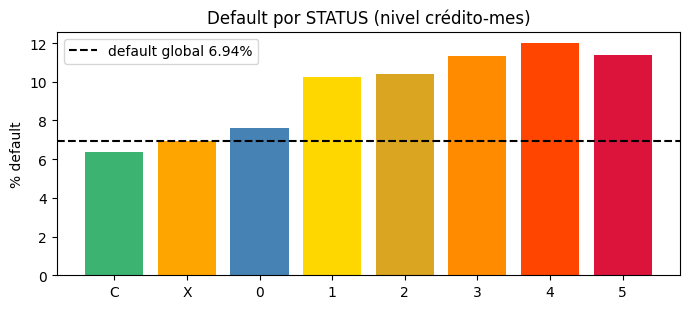

In [15]:
# jerarquía de riesgo por STATUS (nivel crédito-mes, TARGET heredado)
tab = bb_t.groupby("STATUS", observed=True)["TARGET"].agg(n="size", tasa="mean").reindex(orden)
tab["tasa"] = (tab["tasa"] * 100).round(2)
display(tab)

ct = pd.crosstab(bb_t["STATUS"], bb_t["TARGET"])
base = bb_t["TARGET"].mean() * 100
sin_mora = tab.loc[["C", "X", "0"], "n"].sum() / len(bb_t) * 100  # masa pegada a la base que diluye la V
print(f"Chi2 = {chi2_contingency(ct).statistic:,.0f} | V de Cramér = {association(ct, method='cramer', correction=True):.4f} | "
      f"escalón de 0 a 1: {tab.loc['1', 'tasa'] - tab.loc['0', 'tasa']:+.2f}pp | "
      f"masa en C, X y 0: {sin_mora:.2f}% (en mora {100 - sin_mora:.2f}%)")

fig, ax = plt.subplots(figsize=(7, 3.2))
colores = ["mediumseagreen", "orange", COLOR_NODEF, "gold", "goldenrod", "darkorange", "orangered", COLOR_DEF]
ax.bar(orden, tab["tasa"], color=colores)
ax.axhline(base, color="black", ls="--", label=f"default global {base:.2f}%")
ax.set(title="Default por STATUS (nivel crédito-mes)", ylabel="% default")
ax.legend(); plt.tight_layout(); plt.show()

In [16]:
# ¿la escala ordinal aporta sobre la binaria? (solo meses reportados: C y X quedan fuera de escala)
bb_t["dpd"] = pd.to_numeric(bb_t["STATUS"], errors="coerce")  # C y X salen NaN
rep = bb_t["dpd"].notna()
d, t = bb_t.loc[rep, "dpd"].values, bb_t.loc[rep, "TARGET"].values
print(f"meses reportados: {rep.sum():,} ({rep.mean() * 100:.2f}% del histórico enlazado)")

for nombre, v in [("escala de 0 a 5", d), ("binaria DPD > 0", (d > 0).astype(float))]:
    x0, x1 = v[t == 0], v[t == 1]
    u, p = mannwhitneyu(x0, x1)
    r_rb = abs(2 * u / (len(x0) * len(x1)) - 1)
    print(f"{nombre}: Pearson={pearsonr(v, t)[0]:.4f} | Spearman={spearmanr(v, t)[0]:.4f} | rank-biserial={r_rb:.4f} (p={p:.1e})")

meses reportados: 4,836,998 (32.90% del histórico enlazado)


escala de 0 a 5: Pearson=0.0201 | Spearman=0.0230 | rank-biserial=0.0180 (p=0.0e+00)


binaria DPD > 0: Pearson=0.0229 | Spearman=0.0229 | rank-biserial=0.0180 (p=0.0e+00)


créditos: 523,515


,Pearson,Spearman,n
meses_obs,-0.0619,-0.0692,523515
rec_dpd,0.0565,0.0604,67962
pct_dpd,0.0323,0.0341,456399
worst,0.0277,0.0326,456399
n_rep,-0.0188,-0.0187,523515
n_dpd,0.0155,0.0292,523515
pct_X,0.0045,0.0051,523515


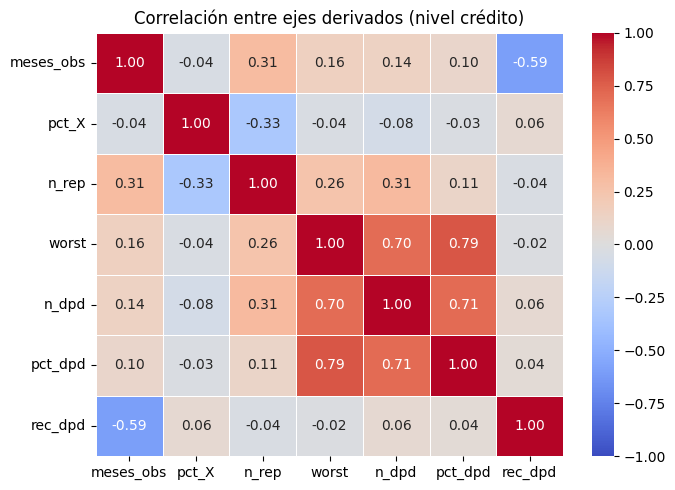

r
worst     pct_dpd  0.7882
n_dpd     pct_dpd  0.7087
worst     n_dpd    0.6976
meses_obs rec_dpd -0.5940
pct_X     n_rep   -0.3261
n_rep     n_dpd    0.3133
meses_obs n_rep    0.3121
n_rep     worst    0.2567
meses_obs worst    0.1562
          n_dpd    0.1354
n_rep     pct_dpd  0.1124
meses_obs pct_dpd  0.0953
pct_X     n_dpd   -0.0769
          rec_dpd  0.0650
n_dpd     rec_dpd  0.0641
meses_obs pct_X   -0.0406
pct_dpd   rec_dpd  0.0397
pct_X     worst   -0.0362
n_rep     rec_dpd -0.0357
pct_X     pct_dpd -0.0309
worst     rec_dpd -0.0178

In [17]:
# ejes derivados a nivel crédito (precursores de las features a nivel cliente)
credf = bb_t.groupby("SK_ID_BUREAU").agg(
    meses_obs=("STATUS", "size"),  # exposición
    pct_X=("isX", "mean"),         # ausencia de reporte
    n_rep=("dpd", "count"),        # meses con estado reportado (0 a 5)
    worst=("dpd", "max"),          # severidad
    n_dpd=("isDPD", "sum"),        # intensidad bruta
    TARGET=("TARGET", "first"),
)
credf["pct_X"] *= 100
credf["pct_dpd"] = credf["n_dpd"] / credf["n_rep"] * 100  # intensidad normalizada por meses reportados
credf["rec_dpd"] = bb_t.loc[bb_t["isDPD"]].groupby("SK_ID_BUREAU")["MONTHS_BALANCE"].max()  # recencia del último DPD
ejes = ["meses_obs", "pct_X", "n_rep", "worst", "n_dpd", "pct_dpd", "rec_dpd"]

# ranking contra TARGET heredado, con la población de cada medición (worst y rec_dpd no existen en todo crédito)
rank = pd.DataFrame({
    "Pearson": credf[ejes].corrwith(credf["TARGET"]),
    "Spearman": credf[ejes].corrwith(credf["TARGET"], method="spearman"),
    "n": credf[ejes].notna().sum(),
}).sort_values("Pearson", key=abs, ascending=False)
print(f"créditos: {len(credf):,}")
display(rank.round(4))

m = credf[ejes].corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(m, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=.5, ax=ax)
ax.set_title("Correlación entre ejes derivados (nivel crédito)")
plt.tight_layout(); plt.show()

# pares ordenados por |r| para leer las hipótesis del bloque (el heatmap solo da 2 decimales)
pares = m.where(np.triu(np.ones(m.shape), k=1).astype(bool)).stack().sort_values(key=abs, ascending=False)
display(pares.round(4).to_frame("r"))

In [18]:
# si la feature entra como flag, la redundancia se mide sobre la binarizada, no sobre el valor crudo
flags = pd.DataFrame({  # sin mes reportado (NaN) la comparación ya da False: no hay evidencia de mora
    "has_dpd": credf["n_dpd"] > 0,
    "grave": credf["worst"] >= 3,
    "writeoff": credf["worst"] == 5,
    "recent_dpd": credf["rec_dpd"] >= -6,
})


def tasa(mask):
    """tasa de default y n de un subconjunto de créditos."""
    return f"{credf.loc[mask, 'TARGET'].mean() * 100:.2f}% (n={int(mask.sum()):,})"


filas = []
for a, b in combinations(flags, 2):
    A, B = flags[a], flags[b]
    inter = int((A & B).sum())
    filas.append({"par": f"{a} vs {b}",
                  "V de Cramér": round(association(pd.crosstab(A, B), method="cramer", correction=True), 4),
                  "Jaccard": round(inter / int((A | B).sum()), 4),
                  "n_1": int(A.sum()), "n_2": int(B.sum()), "comunes": inter})
display(pd.DataFrame(filas))

for c in flags:
    delta = credf.loc[flags[c], "TARGET"].mean() - credf.loc[~flags[c], "TARGET"].mean()
    print(f"{c}: {tasa(flags[c])} vs {tasa(~flags[c])} | delta {delta * 100:+.2f}pp")

# en los pares anidados, ¿la flag ancha tiene señal propia o prestada de la estrecha?
print()
for ancha, estrecha in [("grave", "writeoff"), ("has_dpd", "recent_dpd")]:
    grupos = {"ninguna": ~flags[ancha],
              f"{ancha} sin {estrecha}": flags[ancha] & ~flags[estrecha],
              estrecha: flags[estrecha]}
    print(" | ".join(f"{k} {tasa(v)}" for k, v in grupos.items()))

,par,V de Cramér,Jaccard,n_1,n_2,comunes
0,has_dpd vs grave,0.2713,0.0837,67962,5686,5686
1,has_dpd vs writeoff,0.2146,0.0526,67962,3573,3573
2,has_dpd vs recent_dpd,0.4504,0.2263,67962,15377,15377
3,grave vs writeoff,0.7910,0.6284,5686,3573,3573
4,grave vs recent_dpd,0.1500,0.0790,5686,15377,1542
5,writeoff vs recent_dpd,0.1460,0.0657,3573,15377,1168


has_dpd: 10.34% (n=67,962) vs 7.97% (n=455,553) | delta +2.37pp
grave: 11.01% (n=5,686) vs 8.24% (n=517,829) | delta +2.77pp
writeoff: 12.12% (n=3,573) vs 8.25% (n=519,942) | delta +3.87pp
recent_dpd: 13.19% (n=15,377) vs 8.12% (n=508,138) | delta +5.06pp

ninguna 8.24% (n=517,829) | grave sin writeoff 9.13% (n=2,113) | writeoff 12.12% (n=3,573)
ninguna 7.97% (n=455,553) | has_dpd sin recent_dpd 9.50% (n=52,585) | recent_dpd 13.19% (n=15,377)


La jerarquía por `STATUS` a nivel crédito-mes sale nítida y en tres bloques. Los estados sin mora viva quedan en la base o por debajo, con `C` en 6,39% (n=7.027.575, crédito saldado) y `X` en 6,96% (n=2.837.039) frente al 6,94% global, y `0` sube ligeramente hasta 7,59% (n=4.615.684). El salto lo dan los tramos de DPD: `1` con 10,24%, `2` con 10,40%, `3` con 11,33%, `4` con 11,98% y `5` con 11,39%. El dato que manda es el escalón de `0` a `1`, que vale **+2,65pp**, más que todo el recorrido interno de la mora (de 10,24% a 11,98%, 1,74pp). Cualquier mes en mora, aunque sea el tramo más leve de 1 a 30 días, pesa más que la diferencia entre ser leve o ser grave.

Esto matiza lo que anticipé y es que dije que la severidad fina no sería fiablemente monótona, y de `1` a `4` sí lo es; quien rompe la escala es `5` (11,39%, por debajo del 11,98% de `4`). El motivo no era el que supuse: `5` no es "más días de retraso" sino un estado distinto (fallido), y de hecho a nivel crédito se comporta como el más severo de todos (12,12%). El Chi2 de 10.753 con V de Cramér de 0,0270 reproduce el patrón de Chi2 grande con V pequeña que ya vi en bureau, y se explica porque el 98,49% del histórico enlazado está en `C`, `X` o `0` pegado a la base mientras solo el 1,51% concentra la señal.

Sobre los 4.836.998 meses reportados (32,90% del histórico enlazado) probé si la escala ordinal aporta algo como numérica. La escala de 0 a 5 da Pearson 0,0201 y Spearman 0,0230, un ratio de 1,14 es casi lineal. Y la comparación de codificaciones es la que decide, porque la binaria `DPD > 0` da Pearson 0,0229, un 14% más que la escala completa, con rank-biserial idéntico (0,0180) en las dos. El orden de rangos es el mismo y la distancia entre tramos no aporta nada. Binarizar la mora no pierde información, la gana, lo que cierra la decisión de encoding que aplicaré.

Al bajar a nivel crédito (523.515 créditos) el ranking contra el `TARGET` heredado lo encabezan los meses observados con Pearson -0,0619, seguidos de la recencia del último DPD con +0,0565 (n=67.962), el porcentaje de meses en mora con +0,0323, el peor estado alcanzado con +0,0277, los meses con estado reportado con -0,0188, el número de meses en mora con +0,0155 y el porcentaje de meses sin reportar con +0,0045.

La primera hipótesis que barajaba era el sesgo de exposición, y queda refutada. Esperaba que el conteo bruto de meses en mora estuviese inflado por la duración de la observación, y su correlación con los meses observados es de solo 0,1354. Normalizar sigue mereciendo la pena, porque el porcentaje rinde 0,0323 frente al 0,0155 del conteo bruto, pero no por el motivo que supuse, ya que el denominador informativo no depende de lo que dura el crédito sino de cuánto reporta el buró, como muestran el 0,3121 entre meses observados y meses reportados y el -0,3261 entre el porcentaje de meses sin reportar y los meses reportados.

La segunda hipótesis era que severidad e intensidad fuesen ejes distintos, y también cae. El peor estado alcanzado y el porcentaje de meses en mora correlacionan 0,7882, el conteo de meses en mora y ese porcentaje 0,7087, ambos por encima del umbral de 0,70, y el peor estado con el conteo se queda en 0,6976, justo por debajo. Los tres colapsan en un único eje de "cuánta mora acumula el crédito", así que llevarlos los tres a la agregación sería triplicar la misma variable.

La tercera sí se confirma, y es la más útil: la recencia es un eje propio. La recencia del último DPD correlaciona -0,0178 con el peor estado alcanzado, prácticamente cero, y aun así es la segunda del ranking pese a existir solo en 67.962 créditos, el 13,0% del total. Queda un aviso, y es que correlaciona -0,5940 con los meses observados, por debajo del umbral pero lo bastante alto como para tenerlo presente: un histórico largo permite que el último DPD quede lejos por pura ventana de observación.

La cuarta, que `X` fuese inverso a la mora, se confirma solo en presencia. El porcentaje de meses sin reportar correlaciona -0,0769 con el conteo de meses en mora y 0,0045 con el `TARGET`, o sea ruido. El contraste de medias entre créditos con y sin mora (8,79% de meses en `X` en los créditos con DPD frente al 22,04% en los que nunca lo tuvieron) se sostiene en el signo, pero como continua no hay gradiente, lo que confirma descartar `X` como predictor y conservarlo solo como criterio para el denominador del ratio.

El bloque de flags es el que más cambia mis prioridades, y lo mido sobre la versión binarizada y no sobre el valor crudo. Los deltas ordenan el DPD reciente en +5,06pp (13,19%, n=15.377), el fallido en +3,87pp (12,12%, n=3.573), el DPD grave en +2,77pp (11,01%, n=5.686) y el haber tenido algún DPD en +2,37pp (10,34%, n=67.962). La recencia gana a la severidad, que es el orden contrario al que sugería la jerarquía de `STATUS` a nivel mes.

Los dos pares anidados los resuelvo con la partición residual, para separar señal propia de señal prestada. El DPD grave y el fallido dan V de Cramér de 0,7910, por encima del umbral de 0,50, y los 3.573 créditos fallidos están todos dentro de los 5.686 graves. Al quitarle el fallido, el resto de graves cae a 9,13% (n=2.113) frente al 12,12% del fallido: la señal del grave era prestada, así que conservo el fallido. Esto responde también a lo que anticipé al ver la distribución, cuando dije que trataría los niveles `3`, `4` y `5` agrupados en un "DPD grave" por lo escasos que son: el grupo se puede formar y se mide, pero no sobrevive, porque todo lo que aportaba venía del fallido que lleva dentro. El par de haber tenido algún DPD y haberlo tenido hace poco da V de Cramér de 0,4504 con Jaccard de 0,2263, también anidado, pero el reciente es solo el 22,6% del total, y la partición sale limpia y monótona con sin mora en 7,97% (n=455.553), mora antigua en 9,50% (n=52.585) y mora reciente en 13,19% (n=15.377). Aquí la flag genérica sí tiene señal propia, porque la mora antigua aporta +1,53pp sobre los créditos limpios, pero se queda corta al fusionar dos poblaciones que se separan entre sí por 3,69pp.

En resumen, de aquí salen tres decisiones para la agregación a nivel cliente:

- Codificar la mora como binaria y no como escala de 0 a 5, porque la escala fina no aporta y el escalón está en tener o no tener mora.
- No llevar severidad e intensidad como ejes separados, porque con correlaciones de 0,70 a 0,79 son un solo eje.
- Tratar la recencia como eje independiente, que es donde está la señal más fuerte y donde no hay solape con la severidad.

Todo esto está medido a nivel crédito, ya que los créditos de un mismo cliente comparten `TARGET` y los p-valores salen anticonservadores. La decisión final de redundancia se toma sobre la feature ya agregada a nivel cliente. El gradiente completo de default por tramos de recencia y el papel de `MONTHS_BALANCE` los dejo para el eje temporal.

### 7. Análisis Temporal

créditos con huecos en la ventana: 0 | llegan al mes 0: 66.03% | censurados: 33.97%
default | llega a 0: 8.28% (n=345,670) | censurado: 8.25% (n=177,845)
mediana de la recencia (n=67,962) | absoluta: -15 vs -39 | relativa al fin de ventana: -15 vs -10


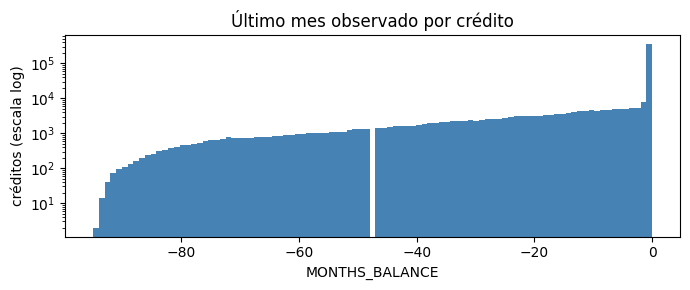

In [19]:
# ¿el histórico de cada crédito llega al mes de la solicitud?
ventana = bb_t.groupby("SK_ID_BUREAU")["MONTHS_BALANCE"].agg(["min", "max"])
credf["fin"] = ventana["max"]
credf["ini"] = credf["fin"] - credf["meses_obs"] + 1
credf["censurado"] = credf["fin"] < 0
print(f"créditos con huecos en la ventana: {int((ventana['min'] != credf['ini']).sum())} | "
      f"llegan al mes 0: {(~credf['censurado']).mean() * 100:.2f}% | censurados: {credf['censurado'].mean() * 100:.2f}%")
print(f"default | llega a 0: {tasa(~credf['censurado'])} | censurado: {tasa(credf['censurado'])}")

# qué le hace la censura a la recencia del último DPD
con = credf[credf["rec_dpd"].notna()]
rel = con["rec_dpd"] - con["fin"]  # meses entre el último DPD y el fin de su ventana
print(f"mediana de la recencia (n={len(con):,}) | absoluta: {con.loc[~con['censurado'], 'rec_dpd'].median():.0f} "
      f"vs {con.loc[con['censurado'], 'rec_dpd'].median():.0f} | "
      f"relativa al fin de ventana: {rel[~con['censurado']].median():.0f} vs {rel[con['censurado']].median():.0f}")

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(credf["fin"], bins=97, color=COLOR_NODEF, log=True)  # el 66% se apila en 0 y aplasta la cola
ax.set(title="Último mes observado por crédito", xlabel="MONTHS_BALANCE", ylabel="créditos (escala log)")
plt.tight_layout(); plt.show()

,n,tasa
bin,,
24m+,33829,8.86
12-24m,12271,10.36
6-12m,7894,11.22
3-6m,4915,12.66
0-3m,9053,13.81


recencia vs TARGET: rank-biserial=0.1144 (p=8.5e-56, n=67,962)


size           mean        
censurado  False  True    False   True 
bin                                    
24m+       17109  16720  0.0781  0.0992
12-24m      8376   3895  0.0924  0.1276
6-12m       6338   1556  0.1021  0.1536
3-6m        4413    502  0.1147  0.2311
0-3m        8892    161  0.1363  0.2360

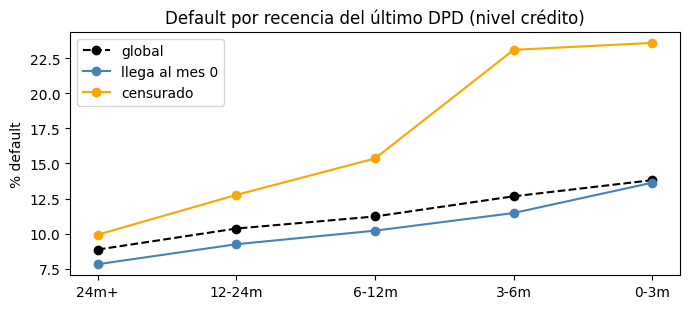

In [20]:
# gradiente de default por recencia del último DPD (solo créditos con algún DPD)
con = credf[credf["rec_dpd"].notna()].copy()
con["bin"] = pd.cut(con["rec_dpd"], [-97, -24, -12, -6, -3, 1], labels=["24m+", "12-24m", "6-12m", "3-6m", "0-3m"])
tabr = con.groupby("bin", observed=True)["TARGET"].agg(n="size", tasa="mean")
tabr["tasa"] = (tabr["tasa"] * 100).round(2)
display(tabr)

x0, x1 = con.loc[con["TARGET"] == 0, "rec_dpd"], con.loc[con["TARGET"] == 1, "rec_dpd"]
u, p = mannwhitneyu(x0, x1)
print(f"recencia vs TARGET: rank-biserial={abs(2 * u / (len(x0) * len(x1)) - 1):.4f} (p={p:.1e}, n={len(con):,})")

# ¿riesgo real o debido a la ventana? el mismo corte dentro de cada estrato de censura
estr = con.pivot_table(index="bin", columns="censurado", values="TARGET", aggfunc=["size", "mean"], observed=True)
display(estr.round(4))

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(tabr.index.astype(str), tabr["tasa"], "o--", color="black", label="global")
for cens, etiqueta, color in [(False, "llega al mes 0", COLOR_NODEF), (True, "censurado", "orange")]:
    ax.plot(tabr.index.astype(str), estr[("mean", cens)] * 100, "o-", color=color, label=etiqueta)
ax.set(title="Default por recencia del último DPD (nivel crédito)", ylabel="% default")
ax.legend(); plt.tight_layout(); plt.show()

In [21]:
# ¿la mora reciente es señal propia o historial corto?
credf["estrato"] = pd.cut(credf["meses_obs"], [0, 12, 24, 48, 97], labels=["0-12m", "13-24m", "25-48m", "49m+"])
for e in credf["estrato"].cat.categories:
    en_estrato = credf["estrato"].eq(e)
    reciente, resto = en_estrato & flags["recent_dpd"], en_estrato & ~flags["recent_dpd"]
    delta = credf.loc[reciente, "TARGET"].mean() - credf.loc[resto, "TARGET"].mean()
    print(f"{e}: mora reciente {tasa(reciente)} vs resto {tasa(resto)} | delta {delta * 100:+.2f}pp")

0-12m: mora reciente 14.56% (n=7,061) vs resto 10.55% (n=146,548) | delta +4.01pp
13-24m: mora reciente 12.96% (n=5,092) vs resto 8.37% (n=125,694) | delta +4.60pp
25-48m: mora reciente 10.32% (n=2,538) vs resto 6.87% (n=146,183) | delta +3.46pp
49m+: mora reciente 11.37% (n=686) vs resto 5.87% (n=89,713) | delta +5.50pp


In [22]:
# ¿el riesgo está en el deterioro reciente o basta con haber tenido mora?
medio = (credf["ini"] + credf["fin"]) / 2
bb_t["mitad_reciente"] = bb_t["MONTHS_BALANCE"].values > bb_t["SK_ID_BUREAU"].map(medio).values
mitad = bb_t.groupby(["SK_ID_BUREAU", "mitad_reciente"])["dpd"].max().unstack(fill_value=0)
tray = credf.join(mitad.set_axis(["w_ant", "w_rec"], axis=1))  # sin mes reportado en una mitad cuenta como 0
tray = tray[tray["meses_obs"] >= 6].fillna({"w_ant": 0, "w_rec": 0})  # ventanas cortas no admiten partición
tray["trayectoria"] = np.select(
    [(tray["w_rec"] == 0) & (tray["w_ant"] == 0), tray["w_rec"] > tray["w_ant"], tray["w_rec"] < tray["w_ant"]],
    ["sin mora", "empeora", "mejora"], default="estable")

tabt = tray.groupby("trayectoria")["TARGET"].agg(n="size", tasa="mean").reindex(["sin mora", "mejora", "estable", "empeora"])
tabt["tasa"] = (tabt["tasa"] * 100).round(2)
display(tabt)
print(f"población: {len(tray):,} créditos con ventana de 6 meses o más")

# ¿mejora real o el crédito deja de reportarse? una mitad sin ningún mes reportado no es comparable
nrep = bb_t.groupby(["SK_ID_BUREAU", "mitad_reciente"])["dpd"].count().unstack(fill_value=0)
tray[["r_ant", "r_rec"]] = nrep.set_axis(["r_ant", "r_rec"], axis=1).reindex(tray.index).fillna(0)
tray["ciega"] = (tray["r_ant"] == 0) | (tray["r_rec"] == 0)
comp = tray[~tray["ciega"]].groupby("trayectoria")["TARGET"].agg(n="size", tasa="mean")
comp["tasa"] = (comp["tasa"] * 100).round(2)
comp["% con una mitad sin reportar"] = (tray.groupby("trayectoria")["ciega"].mean() * 100).round(2)
display(comp.reindex(["sin mora", "mejora", "estable", "empeora"]))

,n,tasa
trayectoria,,
sin mora,404631,7.46
mejora,39931,8.94
estable,9105,12.40
empeora,17095,11.91


población: 470,762 créditos con ventana de 6 meses o más


,n,tasa,% con una mitad sin reportar
trayectoria,,,
sin mora,157225,8.14,61.14
mejora,13664,9.57,65.78
estable,9105,12.40,0.00
empeora,16380,11.98,4.18


STATUS,C,X,0,1,2,3,4,5
STATUS,,,,,,,,
0,5.07,6.89,85.89,2.07,0.05,0.00,0.00,0.01
1,9.17,3.18,46.17,35.17,6.17,0.10,0.00,0.03
2,7.45,4.25,24.93,14.27,17.54,30.81,0.67,0.10
3,7.31,2.95,11.99,5.34,4.73,10.87,55.29,1.51
4,8.11,4.33,6.31,2.48,1.75,2.06,6.54,68.42
5,3.00,2.98,1.80,0.30,0.25,0.13,0.14,91.40


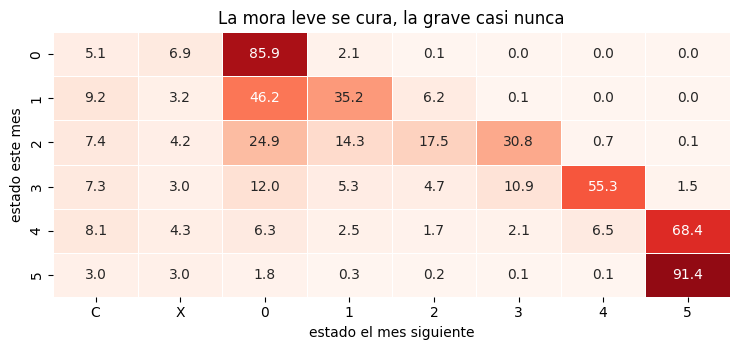

In [23]:
# ¿la mora leve se cura o escala? transición entre meses consecutivos
ev_cred = EvaluadorSenal(credf, credf["TARGET"])  # instancia propia: no contamina el ranking de features a nivel cliente
t = bb_t[["SK_ID_BUREAU", "MONTHS_BALANCE", "STATUS", "dpd", "isDPD", "TARGET"]].sort_values(["SK_ID_BUREAU", "MONTHS_BALANCE"])
sig = t.groupby("SK_ID_BUREAU")["STATUS"].shift(-1).astype(str)
par = (t.groupby("SK_ID_BUREAU")["MONTHS_BALANCE"].shift(-1) - t["MONTHS_BALANCE"] == 1) & t["dpd"].notna()
roll = pd.crosstab(t.loc[par, "STATUS"].astype(str), sig[par], normalize="index").mul(100)
roll = roll.reindex(index=["0", "1", "2", "3", "4", "5"], columns=orden)
display(roll.round(2))

fig, ax = plt.subplots(figsize=(7.5, 3.6))
sns.heatmap(roll, annot=True, fmt=".1f", cmap="Reds", vmin=0, vmax=100, linewidths=.5, cbar=False, ax=ax)
ax.set(title="La mora leve se cura, la grave casi nunca", xlabel="estado el mes siguiente", ylabel="estado este mes")
plt.tight_layout(); plt.show()

,n,tasa
ult,,
C,278937,7.23
X,127153,9.04
0,111872,9.73
1,4106,13.83
2,262,16.41
3,80,17.50
4,62,17.74
5,1043,11.89


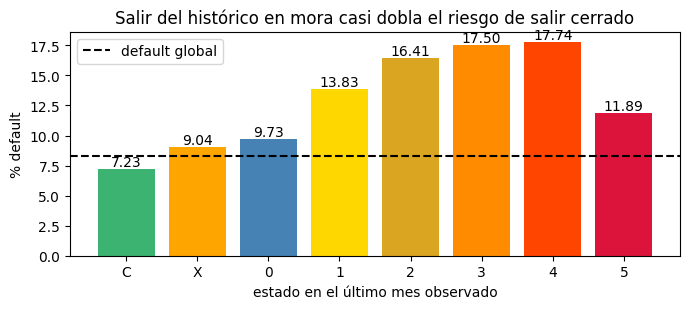

In [24]:
# ¿en qué estado se despide cada crédito del histórico?
credf["ult"] = t.groupby("SK_ID_BUREAU")["STATUS"].last().astype(str)
tabu = credf.groupby("ult", observed=True)["TARGET"].agg(n="size", tasa="mean").reindex(orden)
tabu["tasa"] = (tabu["tasa"] * 100).round(2)
display(tabu)

fig, ax = plt.subplots(figsize=(7, 3.2))
colores = ["mediumseagreen", "orange", COLOR_NODEF, "gold", "goldenrod", "darkorange", "orangered", COLOR_DEF]
barras = ax.bar(orden, tabu["tasa"], color=colores)
ax.bar_label(barras, fmt="%.2f")
ax.axhline(credf["TARGET"].mean() * 100, color="black", ls="--", label="default global")
ax.set(title="Salir del histórico en mora casi dobla el riesgo de salir cerrado",
       ylabel="% default", xlabel="estado en el último mes observado")
ax.legend(); plt.tight_layout(); plt.show()

In [25]:
# tres preguntas que la trayectoria deja abiertas, medidas antes de proponer nada
p1 = t.loc[par & t["STATUS"].astype(str).eq("1")].assign(sig=sig)
escalo = p1.groupby("SK_ID_BUREAU")["sig"].apply(lambda x: x.isin(["2", "3", "4", "5"]).any())
curo = p1.groupby("SK_ID_BUREAU")["sig"].apply(lambda x: x.isin(["0", "C"]).any())
paso_por_1 = credf.index.isin(escalo.index)

nuevo = t["isDPD"] & ~t.groupby("SK_ID_BUREAU")["isDPD"].shift(1, fill_value=False)
credf["episodios"] = nuevo.groupby(t["SK_ID_BUREAU"]).sum()
con_mora = credf["n_dpd"] > 0

ev_cred.evaluar_flags([
    ("escaló desde el primer tramo", escalo.reindex(credf.index, fill_value=False), paso_por_1, "pasaron por el tramo 1"),
    ("curó sin escalar", (curo & ~escalo).reindex(credf.index, fill_value=False), paso_por_1, "pasaron por el tramo 1"),
    ("dos o más episodios de mora", credf["episodios"] >= 2, con_mora, "créditos con mora"),
])
print(f"Pearson entre episodios y meses en mora: {credf.loc[con_mora, 'episodios'].corr(credf.loc[con_mora, 'n_dpd']):.4f}")

# ¿importa cuándo llega el primer impago dentro de la vida observada del crédito?
credf["mes_primer_dpd"] = t.loc[t["isDPD"]].groupby("SK_ID_BUREAU")["MONTHS_BALANCE"].min() - credf["ini"]
bp = pd.cut(credf["mes_primer_dpd"], [-1, 5, 11, 23, 200], labels=["0-5m", "6-11m", "12-23m", "24m+"])
tabp = credf.groupby(bp, observed=True)["TARGET"].agg(n="size", tasa="mean")
tabp["tasa"] = (tabp["tasa"] * 100).round(2)
display(tabp)

Variable,Población,Tasa (1),Tasa (0),Delta,z-stat,p-valor
escaló desde el primer tramo,pasaron por el tramo 1,10.91% (n=7679),10.23% (n=55785),+0.68 pp,1.8,0.06667396820616002
curó sin escalar,pasaron por el tramo 1,9.99% (n=52302),11.84% (n=11162),-1.85 pp,-5.8,5.063168782840551e-09
dos o más episodios de mora,créditos con mora,10.77% (n=20454),10.15% (n=47508),+0.61 pp,2.4,0.015942150222570523


Pearson entre episodios y meses en mora: 0.4043


,n,tasa
mes_primer_dpd,,
0-5m,32423,11.05
6-11m,20821,9.80
12-23m,10704,9.92
24m+,4014,8.45


Antes de medir nada he controlado la ventana de observación, porque la forma del histograma mensual sugería que cada crédito se sigue hasta el mes de la solicitud, y **eso es falso para un tercio de la tabla**: solo el 66,03% llega al mes 0, y 177.845 créditos (33,97%) dejan de reportarse antes. Lo que sí se confirma es que la ventana es perfectamente contigua, con 0 créditos con huecos, así que los meses observados se leen literalmente como una ventana continua y puedo derivar su inicio del final y la longitud.

Esa censura no es riesgo. Los créditos que llegan al mes 0 dan 8,28% de default (n=345.670) y los censurados 8,25% (n=177.845), prácticamente idénticos, así que depende de cómo reporta el buró y no de una característica del cliente. Pero sí **degrada la medición de la recencia**: la mediana del último DPD es de -15 meses en los que llegan al mes 0 y de -39 en los censurados, mientras que medida relativa al fin de su propia ventana las dos convergen (-15 y -10). Es decir, no es que los censurados tuvieran su mora más antigua, es que dejaron de observarse antes. Ahí está la explicación mecánica del -0,5940 entre recencia y meses observados que había dejado anotado como confusor pendiente.

Con eso controlado, el gradiente de recencia sale monótono y limpio sobre los 67.962 créditos con algún DPD: 8,86% cuando el último DPD fue hace más de 24 meses (n=33.829), 10,36% entre 12 y 24, 11,22% entre 6 y 12, 12,66% entre 3 y 6, y 13,81% en los últimos 3 meses (n=9.053). Un span de +4,95pp explicado solo por cuándo, con rank-biserial de 0,1144 (efecto moderado, p=8,5e-56), del mismo orden que el 0,1502 de la longitud de histórico.

El contraste que decide el bloque es el estratificado, porque ese gradiente podría venir de la ventana de observación y no del riesgo. No es el caso: **se sostiene en los dos estratos de censura**, de 7,81% a 13,63% en los créditos que llegan al mes 0 (+5,82pp) y de 9,92% a 23,60% en los censurados (+13,68pp). Y ahí aparece algo que no anticipé, y es que en los censurados el gradiente es mucho más pronunciado. Un crédito que entra en mora justo antes de que el buró deje de seguirlo llega al 23,60% de default, casi el triple de la base. La lectura de negocio es que dejar de reportar un crédito recién impagado apunta a un cierre problemático (venta o traspaso a recobro), lo que enlaza con las categorías 'Sold' y 'Bad debt' de bureau. Lo tomo como indicativo y no como cifra firme, porque esos dos bins tienen n de 161 y 502. El matiz metodológico es que la censura por sí sola no discrimina, pero **interactúa** con la recencia.

Quedaba pendiente saber si la mora reciente no sería simplemente "crédito joven" disfrazado. El test en cuatro estratos de longitud de ventana lo descarta, porque el delta aguanta en los cuatro: +4,01pp de 0 a 12 meses, +4,60pp de 13 a 24, +3,46pp de 25 a 48 y +5,50pp en 49 o más. Y el delta **mayor** está en los históricos largos, justo lo contrario de lo que exigiría la hipótesis de confusión: en un crédito con 49 meses o más de ventana, tener mora en los últimos 6 casi dobla el riesgo (11,37% frente a 5,87%). Es señal propia, el mismo patrón que rescató `BUREAU_DAYS_CREDIT_UPDATE_FLAG` en bureau.

Antes de la trayectoria hay una pregunta más básica que el histórico permite responder y que ninguna otra tabla puede: qué pasa el mes siguiente. La transición entre meses consecutivos deja un punto de no retorno muy marcado. Desde el primer tramo de mora casi la mitad de los créditos vuelve al corriente, el 46,17%, un 35,17% se queda donde está y solo el 6,17% empeora. Pero desde el segundo tramo se invierte, y el 30,81% pasa al tercero; desde el tercero el 55,29% pasa al cuarto, desde el cuarto el 68,42% cae a fallido, y el fallido se retroalimenta al 91,40%. La mora leve es reversible y la grave casi nunca lo es, y eso sostiene por un camino nuevo las dos decisiones de codificación que ya había tomado: el escalón está en entrar en mora, no en el tramo alcanzado, y el fallido merece flag propia porque no es un tramo más sino un estado absorbente.

El mismo eje visto por su final da la otra cara. Mirando en qué estado se despide cada crédito del histórico, el que sale cerrado da 7,23% de default (n=278.937) y el que sale sin reportar 9,04%, mientras que salir en mora cuesta 13,83% en el primer tramo, 16,41% en el segundo, 17,50% en el tercero y 17,74% en el cuarto. El fallido queda en 11,89% porque muchos se marcaron como tal hace años. Salir del histórico impagado es un perfil por sí mismo, y es el mecanismo concreto detrás de que la recencia medida hasta el fin de la ventana rinda más que la medida hasta la solicitud.

Tres preguntas más que rondaban el bloque quedan medidas y ninguna merece feature propia. Escalar desde el primer tramo a tramos peores da +0,68pp con p=0,067, y curar sin escalar -1,85pp con p=5,1e-09, que sí es significativo pero se queda igualmente por debajo del umbral práctico de 2pp: lo que informa es haber entrado en mora, no cómo siguió. Tener varios episodios separados en vez de uno da +0,61pp, con rank-biserial de 0,0129 y correlación 0,4043 con el número de meses en mora, o sea que es casi la misma variable contada de otro modo. Y el primer impago temprano marca un gradiente de 11,05% en los seis primeros meses de vida observada a 8,45% pasados dos años, pero está confundido con la longitud de la ventana, porque un crédito observado poco tiempo solo puede tener impagos tempranos; sin un control estratificado no me lo creo, así que lo dejo medido y fuera.

Por último la trayectoria, que es la única pregunta que solo un histórico mensual puede responder. Esperaba que el deterioro reciente concentrase el riesgo por encima de la recuperación, y se confirma pero con un matiz que no había anticipado. Sobre los 470.762 créditos con ventana de 6 meses o más, sin mora da 7,46% (n=404.631), mejora 8,94% (n=39.931), empeora 11,91% (n=17.095) y **estable 12,40% (n=9.105), que es el más alto de los cuatro**. La mora **persistente**, la que se mantiene en el mismo nivel en las dos mitades de la ventana, pesa más que el deterioro puntual. Y en el extremo opuesto, recuperarse recorta casi todo el exceso de riesgo, porque "mejora" queda a solo +1,48pp de los créditos limpios, mucho más cerca de ellos que de la mora viva.

Hay que mirar de qué está hecha cada categoría antes de darla por buena, porque una mitad de la ventana puede no tener ni un mes con estado reportado. Ahí está el matiz que faltaba: el 65,78% de los créditos que "mejoran" no tiene ningún mes reportado en su mitad reciente, así que no es que mejoren, es que dejan de reportarse, casi siempre porque se cierran. En "empeora" pasa en el 4,18% y en "estable" en ninguno, que es lo coherente con exigir mora viva en las dos mitades. Restringiendo a los créditos con las dos mitades reportadas, que es la comparación limpia, el orden se mantiene entero: 8,14% sin mora (n=157.225), 9,57% mejora (n=13.664), 11,98% empeora (n=16.380) y 12,40% estable (n=9.105). La jerarquía aguanta, pero la etiqueta induce a error, así que la feature tendrá que exigir meses reportados en las dos mitades, o nombrar esa categoría por lo que de verdad contiene, que es mora seguida de cierre.

Eso es información que el peor estado agregado no contiene, porque marca igual a un crédito que se recuperó y a uno que sigue en mora. La trayectoria es por tanto una feature candidata nueva, además de las dos temporales que ya tenía previstas.

En resumen, de aquí salen tres cosas para la agregación a nivel cliente:

- La recencia del último DPD es la señal temporal principal, y es propia, no prestada de la longitud del historial.
- La censura de ventana no es predictor por sí sola, pero hay que llevarla como control, porque desplaza la recencia absoluta e interactúa con ella.
- La trayectoria (sin mora, mejora, estable, empeora) separa mora resuelta de mora persistente y merece entrar como feature propia, definida sobre créditos con las dos mitades de la ventana reportadas.

### 8. Análisis de Outliers

In [26]:
# validez de dominio de las columnas crudas
fuera_mes = int(((bb["MONTHS_BALANCE"] < -96) | (bb["MONTHS_BALANCE"] > 0)).sum())
fuera_status = int((~bb["STATUS"].astype(str).isin(orden)).sum())
print(f"MONTHS_BALANCE fuera de [-96, 0]: {fuera_mes} | STATUS fuera del dominio: {fuera_status}")


# ¿el cierre es absorbente?
esC = bb_t["STATUS"].astype(str).eq("C")
primer_C = bb_t.loc[esC].groupby("SK_ID_BUREAU")["MONTHS_BALANCE"].min()
nC = esC.groupby(bb_t["SK_ID_BUREAU"]).sum()
nX = bb_t["isX"].groupby(bb_t["SK_ID_BUREAU"]).sum()
assert (nC + nX + credf["n_rep"] == credf["meses_obs"]).all(), "C, X y meses reportados no cubren la ventana"

reabre = (bb_t["MONTHS_BALANCE"] > bb_t["SK_ID_BUREAU"].map(primer_C)) & ~esC
print(f"créditos con algún C: {len(primer_C):,} | con estado no-C posterior a su primer C: "
      f"{bb_t.loc[reabre, 'SK_ID_BUREAU'].nunique()} ({int(reabre.sum())} filas: "
      f"{bb_t.loc[reabre, 'STATUS'].astype(str).value_counts().to_dict()})")

# ¿la ventana mensual cuadra con la fecha de apertura del crédito en bureau?
dc = bureau.set_index("SK_ID_BUREAU")["DAYS_CREDIT"].reindex(credf.index)
desfase = credf["meses_obs"] - (-dc / 30.44 + credf["fin"])  # observados menos transcurridos desde la apertura
previos = desfase > 1
print(f"desfase mediana {desfase.median():.1f} meses (p95 {desfase.quantile(.95):.1f}) | ventana anterior a la "
      f"apertura: {int(previos.sum()):,} créditos ({previos.mean() * 100:.2f}%), exceso máximo {desfase.max():.1f} meses")
ev_cred.evaluar_flags([("ventana previa a la apertura", previos, None, "todos los créditos")])

MONTHS_BALANCE fuera de [-96, 0]: 0 | STATUS fuera del dominio: 0


créditos con algún C: 278,937 | con estado no-C posterior a su primer C: 5 (6 filas: {'1': 5, '2': 1})
desfase mediana 0.5 meses (p95 1.0) | ventana anterior a la apertura: 16,014 créditos (3.06%), exceso máximo 1.1 meses


Variable,Población,Tasa (1),Tasa (0),Delta,z-stat,p-valor
ventana previa a la apertura,todos los créditos,8.3% (n=16014),8.27% (n=507501),+0.03 pp,0.1,0.9039170548247353


filas huérfanas: 3,120,184 (11.43% de la tabla)
con padre en bureau: 24,179,741 | de ellas, cliente fuera de train: 9,478,129 (34.72% de la tabla) | analizables: 14,701,612 (53.85%)


,grupo,créditos,meses (mediana),meses (media),% C,% X,% DPD
0,huérfanos,43041,97.0,72.5,67.03,22.29,0.93
1,con padre en bureau,774354,25.0,31.2,47.79,21.15,1.30


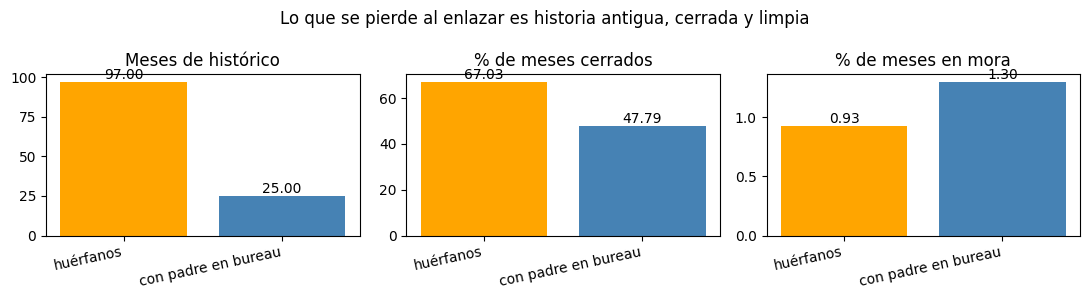

In [27]:
# la pérdida al cruzar con bureau: ¿qué perfil tienen los créditos huérfanos?
huerfano = ~bb["SK_ID_BUREAU"].isin(bureau["SK_ID_BUREAU"])
print(f"filas huérfanas: {int(huerfano.sum()):,} ({huerfano.mean() * 100:.2f}% de la tabla)")

# la otra pérdida, la que no se ve: filas con padre en bureau cuyo cliente no está en train
con_padre = int((~huerfano).sum())
print(f"con padre en bureau: {con_padre:,} | de ellas, cliente fuera de train: {con_padre - len(bb_t):,} "
      f"({(con_padre - len(bb_t)) / len(bb) * 100:.2f}% de la tabla) | analizables: {len(bb_t):,} "
      f"({len(bb_t) / len(bb) * 100:.2f}%)")

perfil = []
for nombre, sub in [("huérfanos", bb[huerfano]), ("con padre en bureau", bb[~huerfano])]:
    s = sub["STATUS"].astype(str)
    meses = sub.groupby("SK_ID_BUREAU").size()
    perfil.append({"grupo": nombre, "créditos": sub["SK_ID_BUREAU"].nunique(),
                   "meses (mediana)": meses.median(), "meses (media)": round(meses.mean(), 1),
                   "% C": round(s.eq("C").mean() * 100, 2), "% X": round(s.eq("X").mean() * 100, 2),
                   "% DPD": round(s.isin(["1", "2", "3", "4", "5"]).mean() * 100, 2)})
tabh = pd.DataFrame(perfil).set_index("grupo")
display(tabh.reset_index())

fig, ax = plt.subplots(1, 3, figsize=(11, 3))
for eje, col, titulo in zip(ax, ["meses (mediana)", "% C", "% DPD"],
                            ["Meses de histórico", "% de meses cerrados", "% de meses en mora"]):
    barras = eje.bar(tabh.index, tabh[col], color=["orange", COLOR_NODEF])
    eje.bar_label(barras, fmt="%.2f")
    eje.set(title=titulo)
    plt.setp(eje.get_xticklabels(), rotation=12, ha="right")
fig.suptitle("Lo que se pierde al enlazar es historia antigua, cerrada y limpia")
plt.tight_layout(); plt.show()

In [28]:
# C y X no son mora, pero tampoco son ausencia de mora: ¿cuántos créditos se quedan sin denominador?
sin_rep = credf["n_rep"].eq(0)
solo_X = credf["pct_X"].eq(100)
print(f"créditos sin ningún estado numérico (solo C y X): {int(sin_rep.sum()):,} ({sin_rep.mean() * 100:.2f}%), "
      f"de los cuales 100% X: {int(solo_X.sum()):,}")

# el extremo del ratio de intensidad, ¿riesgo máximo o denominador de un solo mes?
lleno = credf["pct_dpd"].eq(100)
con_dpd = credf["n_dpd"] > 0
print(f"pct_dpd = 100%: {int(lleno.sum()):,} créditos | meses reportados que lo producen: "
      f"{credf.loc[lleno, 'n_rep'].value_counts().head(4).to_dict()}")
print(f"créditos con un mes reportado o menos: {int(credf['n_rep'].le(1).sum()):,} ({credf['n_rep'].le(1).mean() * 100:.2f}%)")

ev_cred.evaluar_flags([("sin estado numérico", sin_rep, None, "todos los créditos"),
                       ("pct_dpd = 100%", lleno, con_dpd, "créditos con mora")])

créditos sin ningún estado numérico (solo C y X): 67,116 (12.82%), de los cuales 100% X: 47,488
pct_dpd = 100%: 729 créditos | meses reportados que lo producen: {1: 280, 2: 78, 4: 71, 3: 53}
créditos con un mes reportado o menos: 93,033 (17.77%)


Variable,Población,Tasa (1),Tasa (0),Delta,z-stat,p-valor
sin estado numérico,todos los créditos,8.8% (n=67116),8.2% (n=456399),+0.61 pp,5.3,1.0448313121535301e-07
pct_dpd = 100%,créditos con mora,10.01% (n=729),10.34% (n=67233),-0.33 pp,-0.3,0.7733776264700399


,50%,90%,95%,99%,max,Máx/p99,severo
meses_obs,22.0,60.0,77.00,91.00,97.0,1.07,no
n_rep,7.0,21.0,28.00,47.00,96.0,2.04,no
n_dpd,0.0,1.0,2.00,8.00,89.0,11.12,sí
pct_dpd,0.0,10.0,23.08,63.64,100.0,1.57,no
worst,0.0,1.0,1.00,3.00,5.0,1.67,no


Variable,Población,Tasa (1),Tasa (0),Delta,z-stat,p-valor
n_dpd > p99,créditos con mora,10.27% (n=4890),10.34% (n=63072),-0.08 pp,-0.2,0.8659251809969948


,n,tasa
n_dpd,,
0,455553,7.97
1,32862,9.94
2-3,19644,10.69
4-8,10566,10.97
9+,4890,10.27


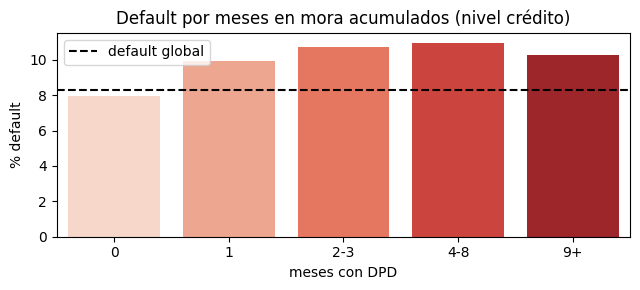

In [29]:
# percentiles y criterio de severo (Máx > 3xp99) sobre los ejes derivados a nivel crédito
derivados = ["meses_obs", "n_rep", "n_dpd", "pct_dpd", "worst"]
perc = credf[derivados].describe(percentiles=[.5, .9, .95, .99]).T[["50%", "90%", "95%", "99%", "max"]]
perc["Máx/p99"] = (perc["max"] / perc["99%"]).round(2)
perc["severo"] = np.where(perc["max"] > 3 * perc["99%"], "sí", "no")
display(perc.round(2))

# la cola se compara contra el resto de créditos con mora, no contra los limpios
sev = credf["n_dpd"] > credf["n_dpd"].quantile(.99)
ev_cred.evaluar_flags([("n_dpd > p99", sev, con_dpd, "créditos con mora")])

binsn = pd.cut(credf["n_dpd"], [-1, 0, 1, 3, 8, 100], labels=["0", "1", "2-3", "4-8", "9+"])
tabn = credf.groupby(binsn, observed=True)["TARGET"].agg(n="size", tasa="mean")
tabn["tasa"] = (tabn["tasa"] * 100).round(2)
display(tabn)

fig, ax = plt.subplots(figsize=(6.5, 3))
etiquetas = tabn.index.astype(str)
sns.barplot(x=etiquetas, y=tabn["tasa"], hue=etiquetas, palette="Reds", legend=False, ax=ax)
ax.axhline(credf["TARGET"].mean() * 100, color="black", ls="--", label="default global")
ax.set(title="Default por meses en mora acumulados (nivel crédito)", xlabel="meses con DPD", ylabel="% default")
ax.legend(); plt.tight_layout(); plt.show()

créditos con histórico por cliente: mediana 5, p99 21, máx 116 (Máx/p99 = 5.52)


,n,tasa
1-2,24400,8.70
3-5,30079,7.60
6-10,25933,7.90
11-21,11070,8.74
22+,749,11.08


comparaciones de calidad de dato: 7 | Bonferroni: alpha = 0.0071


,grupo,n,% default,% Sold + Bad debt,% Closed,% Active
0,censurado con DPD al final,5755,14.42,0.52,70.13,29.35
1,censurado sin DPD al final,172090,8.05,0.46,77.76,21.78
2,llega al mes 0,345670,8.28,0.36,55.03,44.61


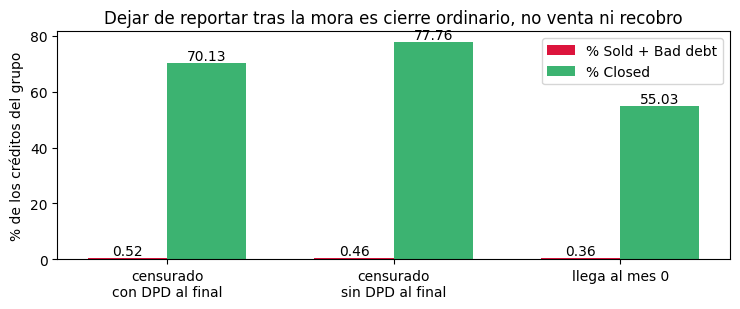

In [30]:
# cola a nivel cliente: créditos con histórico por cliente
n_cred_cli = map_bc.groupby("SK_ID_CURR").size()
p99_cli = n_cred_cli.quantile(.99)
print(f"créditos con histórico por cliente: mediana {n_cred_cli.median():.0f}, p99 {p99_cli:.0f}, "
      f"máx {n_cred_cli.max()} (Máx/p99 = {n_cred_cli.max() / p99_cli:.2f})")
binsc = pd.cut(n_cred_cli, [0, 2, 5, 10, 21, 200], labels=["1-2", "3-5", "6-10", "11-21", "22+"])
tabc = tgt_cli.reindex(n_cred_cli.index).groupby(binsc, observed=True).agg(n="size", tasa="mean")
tabc["tasa"] = (tabc["tasa"] * 100).round(2)
display(tabc)

alpha_cd = 0.05 / len(ev_cred.fb_comparisons)  # familia propia de esta sección, separada de la de features
print(f"comparaciones de calidad de dato: {len(ev_cred.fb_comparisons)} | Bonferroni: alpha = {alpha_cd:.4f}")

credf["activo"] = bureau.set_index("SK_ID_BUREAU")["CREDIT_ACTIVE"].reindex(credf.index).astype(str)
cens_dpd = credf["censurado"] & credf["rec_dpd"].ge(credf["fin"] - 3)  # DPD en los últimos 3 meses de su ventana
grupos = {"censurado con DPD al final": cens_dpd,
          "censurado sin DPD al final": credf["censurado"] & ~cens_dpd,
          "llega al mes 0": ~credf["censurado"]}

filas = []
for k, m in grupos.items():
    vc = credf.loc[m, "activo"].value_counts(normalize=True).mul(100)
    filas.append({"grupo": k, "n": int(m.sum()), "% default": round(credf.loc[m, "TARGET"].mean() * 100, 2),
                  "% Sold + Bad debt": round(vc.get("Sold", 0) + vc.get("Bad debt", 0), 2),
                  "% Closed": round(vc.get("Closed", 0), 2), "% Active": round(vc.get("Active", 0), 2)})
tabx = pd.DataFrame(filas).set_index("grupo")
display(tabx.reset_index())

fig, ax = plt.subplots(figsize=(7.5, 3.2))
x = np.arange(len(tabx))
for k, (col, color) in enumerate([("% Sold + Bad debt", COLOR_DEF), ("% Closed", "mediumseagreen")]):
    barras = ax.bar(x + k * 0.35 - 0.175, tabx[col], 0.35, color=color, label=col)
    ax.bar_label(barras, fmt="%.2f")
ax.set_xticks(x)
ax.set_xticklabels([g.replace("censurado ", "censurado\n") for g in tabx.index])
ax.set(title="Dejar de reportar tras la mora es cierre ordinario, no venta ni recobro", ylabel="% de los créditos del grupo")
ax.legend(); plt.tight_layout(); plt.show()

El histórico mensual del buró no tiene ninguna variable financiera: los estados son ocho códigos discretos y el eje temporal vive en un rango cerrado de -96 a 0, los dos acotados por construcción. Eso descarta de entrada el problema habitual de los importes (colas de millones que pueden ser error de captura) y desplaza el riesgo de dato a otros tres sitios: el denominador de los ratios de mora, lo que se pierde al enlazar con `bureau`, y la cola de las variables que yo mismo derivo del histórico.

En validez de dominio no hay nada que revertir: 0 valores del eje temporal fuera de rango y 0 códigos de estado fuera del dominio. Es lo contrario de lo que encontré en `bureau`, donde hay importes de 396M y fechas de cierre de hace 115 años que habrá que anular o capar aunque tengan señal. Aquí el criterio de validez de dominio no retira ni una observación.

El control lógico que sí me importaba es si el cierre es absorbente, porque el análisis de trayectoria parte de que un crédito cerrado no vuelve a reportar. De los 278.937 créditos con algún mes en `C`, solo 5 tienen un estado distinto posterior a su primer cierre, y son 6 filas en total (cinco en `1` y una en `2`). Con esa magnitud lo trato como ruido de reporte y doy la trayectoria por bien construida.

El segundo control es de coherencia con `bureau`, y consiste en comprobar que la ventana mensual encaja con la fecha de apertura del crédito. El desfase entre los meses observados y los transcurridos desde `DAYS_CREDIT` tiene mediana de 0,5 meses y p95 de 1,0, o sea que el histórico arranca justo en la apertura. Hay 16.014 créditos (3,06%) cuya ventana parece empezar antes de que el crédito exista, pero el exceso máximo es de 1,1 meses y no discriminan (8,30% frente a 8,27%, p=0,90): es el redondeo de 30,44 días por mes, no una inconsistencia de dato.

La calidad del enlace sí deja un hallazgo, y cierra el pendiente que dejé abierto al medir la cobertura. Esperaba que los créditos huérfanos, los que aparecen en el histórico mensual pero no en `bureau`, fuesen una pérdida neutra, y no lo son: esos 43.041 créditos suman 3.120.184 filas, el 11,43% de la tabla, y tienen otro perfil. Su mediana es de 97 meses de histórico frente a 25 de los enlazables, con 67,03% de meses cerrados frente a 47,79% y 0,93% de meses en mora frente a 1,30%. La única de las cuatro métricas del perfil que no los separa es el porcentaje de meses sin reportar, 22,29% frente a 21,15%, así que el perfil es nítido en antigüedad, cierre y mora, pero no en calidad de reporte. Lo que el cruce descarta es historia antigua, cerrada y limpia. Pero esa caracterización cubre solo una parte de lo que se pierde: por encima de los huérfanos hay una segunda merma, mayor y de otra naturaleza, porque 9.478.129 filas más, el 34,72% de la tabla, tienen su crédito en `bureau` pero su cliente fuera de train. Esa es benigna por construcción, ya que son clientes de test, pero conviene tenerla contada, porque entre las dos lo analizable se queda en 14.701.612 filas, el 53,85% del histórico. La pérdida no es aleatoria, pero va en una dirección conocida y benigna para lo que me interesa, porque no infla artificialmente la mora de la muestra que sí puedo analizar. No puedo medir su default, porque sin `bureau` no hay cliente al que atribuirlo, así que lo dejo documentado como sesgo de cobertura y no como algo a corregir.

El bloque con más consecuencias para la agregación es el del denominador. Ya había concluido que el estado `X` es ausencia de dato y que `C` está fuera de la escala de mora, y aquí veo cuántos créditos se quedan sin ningún estado numérico por esa vía: 67.116 (12,82%), de los cuales 47.488 no tienen más que `X` en toda su ventana. Su default es 8,80% frente a 8,20% (+0,61pp, z=5,3, p=1,04e-07), otra vez significancia por volumen con un efecto muy por debajo del umbral práctico de 2pp, y la única de las siete comparaciones que acumula el análisis a nivel de crédito que aguanta su umbral de Bonferroni (0,0071). La consecuencia no es que haya que crear una feature con ellos, es que no se pueden confundir con créditos sin mora: al agregar, su severidad y su intensidad tienen que quedar en `NaN`, nunca en 0, porque fusionar "sin dato" con "sin mora" es exactamente la codificación que diluye la señal rara.

El mismo problema de denominador ataca al ratio de intensidad por el otro extremo. Los 729 créditos que pasaron el 100% de sus meses reportados en mora no son los más morosos del histórico, son los que tienen el denominador más pequeño: 280 de ellos alcanzan ese 100% con un único mes reportado. Y no discriminan, porque dan 10,01% frente al 10,34% del resto de créditos con mora (p=0,77). Con 93.033 créditos (17,77%) por debajo de dos meses reportados, la lectura es que el porcentaje de meses en mora necesita un denominador mínimo para ser interpretable, o directamente cede el sitio al conteo y a la recencia.

Con eso controlado, la cola de las variables derivadas sale corta. Aplicando el criterio de severo (Máx > 3xp99), los meses observados (1,07), los meses reportados (2,04), el porcentaje de meses en mora (1,57) y el peor estado alcanzado (1,67) no lo cumplen, porque los cuatro están acotados por la ventana o por la escala. El único severo es el número de meses en mora, con un máximo de 89 frente a un p99 de 8, un ratio de 11,12. Esperaba que ese extremo fuese el moroso crónico y que rindiese como tal, y no es así: medido contra el resto de créditos con mora, y no contra los limpios, para no mezclarlo con el efecto de tener mora, la cola da 10,27% frente a 10,34% (p=0,87). El gradiente completo lo explica mejor que el test: 7,97% sin ningún mes en mora, 9,94% con uno, 10,69% con dos o tres, 10,97% con cuatro a ocho y 10,27% con nueve o más. La señal salta en el primer mes de mora y luego satura, incluso cae en el último tramo. Acumular meses no añade nada sobre haberla tenido, que es la misma conclusión que ya daban la comparación entre la escala ordinal y la binaria, y el hecho de que la recencia gane a la severidad.

A nivel cliente sí queda una cola con señal. El número de créditos con histórico por cliente tiene mediana 5, p99 de 21 y un máximo de 116, un ratio de 5,52 sobre el p99 y exactamente el mismo tope que el conteo de créditos de `bureau`, así que probablemente es el mismo cliente. El patrón por tramos es la misma U que ya vi allí (8,70% con uno o dos créditos, 7,60% con tres a cinco, 7,90% con seis a diez, 8,74% con once a veintiuno) y la cola se despega: 11,08% en los 749 clientes con 22 créditos o más. No es error de captura y no lo capo. Lo que sí hace es matizar el descarte del conteo de créditos con histórico: la variable continua es ruido, pero su extremo marca riesgo, así que si entra lo hará como flag de cola y no como conteo.

Al controlar la ventana de observación vi que un crédito que entra en mora justo antes de dejar de reportarse llega al 23,60% de default, y lo interpreté como cierre problemático, apuntando a venta o traspaso a recobro y por tanto a las categorías 'Sold' y 'Bad debt' de `bureau`. Lo dejé marcado como indicativo y aquí lo verifico cruzando con el estado del crédito, y el mecanismo concreto **queda refutado**: los 5.755 créditos censurados con mora en los últimos tres meses de su ventana tienen un 0,52% de 'Sold' más 'Bad debt', prácticamente lo mismo que los censurados sin mora al final (0,46%) y que los que llegan al mes de la solicitud (0,36%). Lo que sí cambia, y mucho, es el cierre ordinario: 70,13% de 'Closed' frente al 55,03% de los que llegan al mes de la solicitud. Así que la mitad de la lectura se sostiene, porque dejar de reportar tras la mora es un cierre y el riesgo es real (14,42% de default frente al 8,05% de los censurados sin mora al final), y la otra mitad no, porque el buró no los etiqueta como venta ni como recobro. Es una diferencia de reporte, no de gravedad, y la corrijo para no arrastrar una explicación causal que los datos no sostienen.

Cierro con el aviso metodológico que condiciona todo el análisis a nivel de crédito y de mes. Los 14.701.612 crédito-mes con TARGET no son observaciones independientes: cuelgan de 92.231 clientes que comparten su etiqueta, y un crédito con ventana larga aporta decenas de filas con el mismo valor. Eso hace anticonservadores sus p-valores, que es por lo que aquí decido por tamaño del efecto y no por significancia, y por lo que toda cifra medida sobre el histórico mensual es orientativa hasta que se revalide a nivel cliente.

Lo que queda para la agregación:

- El dato crudo está limpio y las colas que existen son reales.
- Los créditos sin ningún estado numérico van a `NaN` en severidad e intensidad, nunca a 0.
- La intensidad normalizada necesita denominador mínimo, o cede el sitio al conteo y a la recencia, que es lo que la evidencia venía pidiendo.
- El sesgo de cobertura de los huérfanos queda documentado: lo que se pierde al enlazar es historia antigua, cerrada y con menos mora.

### 9. Estrategia de agregación (nivel cliente)

El objetivo vive a nivel cliente y el dato a nivel crédito-mes, así que agrego en dos escalones: de los meses al crédito, y de los créditos al cliente pasando por `bureau`, que es quien aporta el identificador. La cobertura resultante es de 92.231 clientes (29,99% de train), y como el 99,78% de ellos tiene cubiertos todos sus créditos, un cliente marcado sin mora lo está sobre su historial completo y no sobre el trozo que el buró reportó.

| Feature | Cómo se calcula | Por qué |
|---|---|---|
| `BB_RECENT_DPD_FLAG` | algún crédito con DPD en los últimos 6 meses contados hasta la solicitud | mora reciente en codificación absoluta, +4,89pp a nivel cliente, se mide para contrastarla contra la relativa |
| `BB_RECENT_DPD_FLAG_REL` | lo mismo, contando hasta el fin de la ventana observada de cada crédito | +4,92pp y sobre más clientes, es la codificación que sobrevive |
| `BB_EXITS_IN_DPD_FLAG` | algún crédito cuyo último mes observado está en mora | +5,37pp, el delta más alto de la tabla, como nivel adicional dentro de la mora reciente |
| `BB_MONTHS_SINCE_LAST_DPD` | mes más reciente con DPD entre sus créditos, contado hasta la solicitud | recencia continua absoluta, 0,1379 |
| `BB_MONTHS_SINCE_LAST_DPD_REL` | lo mismo, contado hasta el fin de la ventana de cada crédito | 0,1584, la continua más alta del ranking, y entra en tramos |
| `BB_ANY_DPD_FLAG` | algún mes en mora en algún crédito | +2,74pp a nivel cliente, con mucha más cobertura que la mora reciente |
| `BB_OVERDUE_UNION` | mora del histórico mensual o mora reportada en `bureau` | si ninguna fuente domina a la otra, la codificación correcta es la unión |
| `BB_WRITEOFF_FLAG` | algún crédito llega a fallido | +2,94pp a nivel cliente, y absorbe a la mora grave |
| `BB_PCT_MONTHS_DPD` | meses en mora entre meses con estado reportado, con mínimo de denominador | intensidad de la mora |
| `BB_STATUS_WORST` | peor estado alcanzado entre sus créditos, en la escala de 0 a 5 sin binarizar | severidad como escala, se mide para decidirla con evidencia |
| `BB_STATUS_WORST > 0` | flag derivada de la anterior, algún crédito que llega a estado numérico por encima de 0 | severidad como presencia, para contrastarla contra la mora genérica |
| `BB_TRAJECTORY` | peor estado de la mitad reciente frente al de la antigua, solo con las dos mitades reportadas | separa mora resuelta de persistente |
| `BB_CREDITS_WITH_DPD_COUNT` | número de créditos con algún mes en mora | extensión de la mora entre productos |
| `BB_MONTHS_MAX` y `BB_MONTHS_TOTAL` | histórico más largo y suma de meses observados | longitud de historial, se miden para descartarlas con evidencia |
| `BB_MANY_CREDITS_FLAG` | 22 créditos o más con histórico | el conteo es plano salvo en su cola, que salta a 11,08% |
| `HAS_BUREAU_BALANCE` | cliente con histórico mensual | control de composición |

Cuatro reglas condicionan cómo se construyen esas columnas. La mora entra binarizada y no en escala. Severidad e intensidad correlacionan a 0,7882, así que mido las dos y conservo una. El denominador de la intensidad son los meses con estado reportado y con un mínimo exigido, nunca los meses observados. Y los 67.116 créditos sin ningún estado numérico van a valor ausente en severidad e intensidad, nunca a cero, porque fusionar "sin dato" con "sin mora" diluye justo la señal rara que busco. La censura de ventana viaja como control, no como feature.

Toda feature se mide condicionada a tener histórico, porque el relleno con cero mete a los 215.280 clientes sin histórico en el grupo 0 y distorsiona la comparación. Y los cruces con la tasa de default son descriptivos sobre el train completo: cualquier decisión que dependa del objetivo se reconfirma sobre el split de entrenamiento.

### 10. Validación por bloques (TARGET real)

In [31]:
# de crédito a cliente: la agregación parte del resumen por crédito ya validado
cf = credf.join(flags).join(map_bc.set_index("SK_ID_BUREAU"))
bbc = cf.groupby("SK_ID_CURR").agg(
    BB_N_CREDITS_WBAL=("meses_obs", "size"),
    BB_MONTHS_TOTAL=("meses_obs", "sum"),
    BB_MONTHS_MAX=("meses_obs", "max"),
    BB_MONTHS_REPORTED=("n_rep", "sum"),
    BB_STATUS_WORST=("worst", "max"),               # ausente si ningún crédito reporta estado
    BB_ANY_DPD_FLAG=("has_dpd", "max"),
    BB_RECENT_DPD_FLAG=("recent_dpd", "max"),
    BB_WRITEOFF_FLAG=("writeoff", "max"),
    BB_CREDITS_WITH_DPD_COUNT=("has_dpd", "sum"),
    BB_DPD_MONTHS_COUNT=("n_dpd", "sum"),
    BB_MONTHS_SINCE_LAST_DPD=("rec_dpd", "max"),
    BB_CENSORED_RATIO=("censurado", "mean"),  # control de ventana, no predictor
)
sin_rep = bbc["BB_MONTHS_REPORTED"].eq(0)
bbc["BB_PCT_MONTHS_DPD"] = bbc["BB_DPD_MONTHS_COUNT"] / bbc["BB_MONTHS_REPORTED"].replace(0, np.nan) * 100
bbc.loc[sin_rep, ["BB_DPD_MONTHS_COUNT", "BB_CREDITS_WITH_DPD_COUNT"]] = np.nan  # sin dato no es sin mora

df = train[["SK_ID_CURR", "TARGET"]].merge(bbc, on="SK_ID_CURR", how="left")
df["HAS_BUREAU_BALANCE"] = df["BB_N_CREDITS_WBAL"].notna().astype("int8")
has = df["HAS_BUREAU_BALANCE"].eq(1).values

assert len(df) == len(train) and (df["TARGET"].values == target).all(), "el left join alteró filas u orden"
assert int(has.sum()) == cli_hist, "clientes con histórico no cuadra con la cobertura medida"
assert int(df["BB_MONTHS_TOTAL"].sum()) == len(bb_t), "la doble agregación pierde o duplica meses"
print(f"clientes: {len(df):,} | con histórico mensual: {int(has.sum()):,} | "
      f"créditos agregados: {int(df['BB_N_CREDITS_WBAL'].sum()):,}")
print(f"sin ningún mes con estado reportado: {int(sin_rep.sum()):,} "
      f"({sin_rep.mean() * 100:.2f}% de los que tienen histórico), con severidad e intensidad ausentes")

ev = EvaluadorSenal(df, target)  # instancia a nivel cliente, separada de la de calidad de dato

clientes: 307,511 | con histórico mensual: 92,231 | créditos agregados: 523,515
sin ningún mes con estado reportado: 2,375 (2.58% de los que tienen histórico), con severidad e intensidad ausentes


,grupo,n,% default
0,sin histórico,215280,8.04
1,con histórico sin mora,61179,7.22
2,con histórico y mora,31052,9.96


Variable,Población,Tasa (1),Tasa (0),Delta,z-stat,p-valor
HAS_BUREAU_BALANCE,global,8.14% (n=92231),8.04% (n=215280),+0.10 pp,0.9,0.3529435513429273


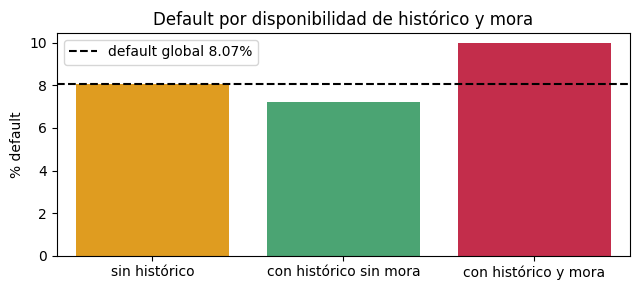

In [32]:
# el 0 de una flag agregada no es un grupo homogéneo: sin histórico y sin mora son cosas distintas
any_dpd = df["BB_ANY_DPD_FLAG"].fillna(0).eq(1).values
grupos = {"sin histórico": ~has, "con histórico sin mora": has & ~any_dpd, "con histórico y mora": has & any_dpd}
tabp = pd.DataFrame([{"grupo": k, "n": int(m.sum()), "% default": round(target[m].mean() * 100, 2)}
                     for k, m in grupos.items()])
display(tabp)
ev.evaluar_flags([("HAS_BUREAU_BALANCE", df["HAS_BUREAU_BALANCE"].values, None, "global")])

fig, ax = plt.subplots(figsize=(6.5, 3))
sns.barplot(x="grupo", y="% default", data=tabp, hue="grupo",
            palette=["orange", "mediumseagreen", COLOR_DEF], legend=False, ax=ax)
ax.axhline(target.mean() * 100, color="black", ls="--", label=f"default global {target.mean() * 100:.2f}%")
ax.set(title="Default por disponibilidad de histórico y mora", xlabel="", ylabel="% default")
ax.legend(); plt.tight_layout(); plt.show()

In [33]:
# las tres flags de mora, medidas en global y condicionadas a tener histórico
items = []
for c in ["BB_ANY_DPD_FLAG", "BB_RECENT_DPD_FLAG", "BB_WRITEOFF_FLAG"]:
    v = df[c].fillna(0).values
    items += [(c, v, None, "global (nulo=0)"), (c, v, has, "con histórico")]
ev.evaluar_flags(items)

# ¿tres flags o la misma repetida tres veces?
fl = pd.DataFrame({c: df[c].fillna(0).eq(1).values[has] for c in
                   ["BB_ANY_DPD_FLAG", "BB_RECENT_DPD_FLAG", "BB_WRITEOFF_FLAG"]})
t_has = target[has]
filas = []
for a, b in combinations(fl, 2):
    A, B = fl[a], fl[b]
    filas.append({"par": f"{a} vs {b}",
                  "V de Cramér": round(association(pd.crosstab(A, B), method="cramer", correction=True), 4),
                  "Jaccard": round(int((A & B).sum()) / int((A | B).sum()), 4),
                  "n_1": int(A.sum()), "n_2": int(B.sum()), "comunes": int((A & B).sum())})
display(pd.DataFrame(filas))


def tasa_cli(mask):
    """tasa de default y n dentro de los clientes con histórico."""
    return f"{t_has[mask.values].mean() * 100:.2f}% (n={int(mask.sum()):,})"


# en los pares anidados, ¿qué queda de la flag ancha al quitarle la estrecha?
for ancha, estrecha in [("BB_ANY_DPD_FLAG", "BB_WRITEOFF_FLAG"), ("BB_ANY_DPD_FLAG", "BB_RECENT_DPD_FLAG")]:
    print(f"ninguna {tasa_cli(~fl[ancha])} | {ancha} sin {estrecha} {tasa_cli(fl[ancha] & ~fl[estrecha])} | "
          f"{estrecha} {tasa_cli(fl[estrecha])}")

Variable,Población,Tasa (1),Tasa (0),Delta,z-stat,p-valor
BB_ANY_DPD_FLAG,global (nulo=0),9.96% (n=31052),7.86% (n=276459),+2.10 pp,12.9,7.841153374458074e-38
BB_ANY_DPD_FLAG,con histórico,9.96% (n=31052),7.22% (n=61179),+2.74 pp,14.4,9.491117769601136e-47
BB_RECENT_DPD_FLAG,global (nulo=0),12.42% (n=11602),7.9% (n=295909),+4.52 pp,17.5,9.552880891964734e-69
BB_RECENT_DPD_FLAG,con histórico,12.42% (n=11602),7.53% (n=80629),+4.89 pp,18.0,1.3846285031535888e-72
BB_WRITEOFF_FLAG,global (nulo=0),11.02% (n=2206),8.05% (n=305305),+2.96 pp,5.1,3.5512688646256423e-07
BB_WRITEOFF_FLAG,con histórico,11.02% (n=2206),8.07% (n=90025),+2.94 pp,5.0,5.921177452609878e-07


,par,V de Cramér,Jaccard,n_1,n_2,comunes
0,BB_ANY_DPD_FLAG vs BB_RECENT_DPD_FLAG,0.5324,0.3736,31052,11602,11602
1,BB_ANY_DPD_FLAG vs BB_WRITEOFF_FLAG,0.2196,0.0710,31052,2206,2206
2,BB_RECENT_DPD_FLAG vs BB_WRITEOFF_FLAG,0.1705,0.0844,11602,2206,1075


ninguna 7.22% (n=61,179) | BB_ANY_DPD_FLAG sin BB_WRITEOFF_FLAG 9.88% (n=28,846) | BB_WRITEOFF_FLAG 11.02% (n=2,206)
ninguna 7.22% (n=61,179) | BB_ANY_DPD_FLAG sin BB_RECENT_DPD_FLAG 8.49% (n=19,450) | BB_RECENT_DPD_FLAG 12.42% (n=11,602)


,n,tasa
BB_STATUS_WORST,,
0.0,58804,7.20
1.0,24686,10.06
2.0,2961,8.75
3.0,794,8.56
4.0,405,9.63
5.0,2206,11.02


Variable,Población,Tasa (1),Tasa (0),Delta,z-stat,p-valor
BB_STATUS_WORST > 0,con estado reportado,9.96% (n=31052),7.2% (n=58804),+2.76 pp,14.4,8.742731802769475e-47


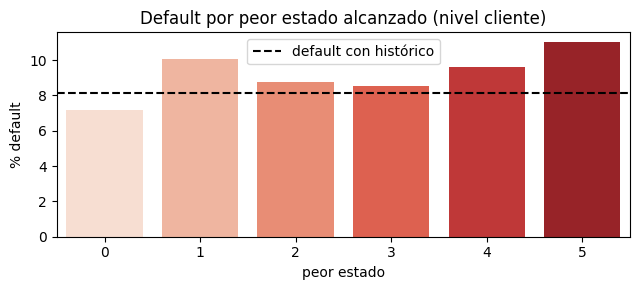

In [34]:
# ¿aporta el peor estado alcanzado, o solo el hecho de haber tenido mora?
sev = df["BB_STATUS_WORST"]
tabs = df.groupby(sev, observed=True)["TARGET"].agg(n="size", tasa="mean")
tabs["tasa"] = (tabs["tasa"] * 100).round(2)
display(tabs)
ev.evaluar_flags([("BB_STATUS_WORST > 0", sev.gt(0).values, sev.notna().values, "con estado reportado")])

fig, ax = plt.subplots(figsize=(6.5, 3))
etiquetas = tabs.index.astype(int).astype(str)
sns.barplot(x=etiquetas, y=tabs["tasa"], hue=etiquetas, palette="Reds", legend=False, ax=ax)
ax.axhline(t_has.mean() * 100, color="black", ls="--", label="default con histórico")
ax.set(title="Default por peor estado alcanzado (nivel cliente)", xlabel="peor estado", ylabel="% default")
ax.legend(); plt.tight_layout(); plt.show()

In [35]:
# ¿siguen siendo un solo eje al agregar por cliente?
ejes = ["BB_STATUS_WORST", "BB_PCT_MONTHS_DPD", "BB_DPD_MONTHS_COUNT", "BB_CREDITS_WITH_DPD_COUNT"]
display(df.loc[has, ejes].corr().round(4))

# dentro de los clientes que ya tienen mora, ¿discrimina algo más?
ev.evaluar_continuas([(c, False, any_dpd, "clientes con mora") for c in ejes])

bins_int = pd.cut(df["BB_PCT_MONTHS_DPD"], [0, 5, 10, 25, 50, 101], labels=["0-5%", "5-10%", "10-25%", "25-50%", "50%+"])
tabi = df[any_dpd].groupby(bins_int[any_dpd], observed=True)["TARGET"].agg(n="size", tasa="mean")
tabi["tasa"] = (tabi["tasa"] * 100).round(2)
display(tabi)

,BB_STATUS_WORST,BB_PCT_MONTHS_DPD,BB_DPD_MONTHS_COUNT,BB_CREDITS_WITH_DPD_COUNT
BB_STATUS_WORST,1.0000,0.6812,0.5953,0.5644
BB_PCT_MONTHS_DPD,0.6812,1.0000,0.6586,0.4725
BB_DPD_MONTHS_COUNT,0.5953,0.6586,1.0000,0.5680
BB_CREDITS_WITH_DPD_COUNT,0.5644,0.4725,0.5680,1.0000


Variable,Población,n,Rank-Biserial,p-valor,Mediana (0),Mediana (1)
BB_STATUS_WORST,clientes con mora,31052,0.0065,0.4009080949776661,1.0,1.0
BB_PCT_MONTHS_DPD,clientes con mora,31052,0.1035,3.1999056358594695e-21,6.2,7.7
BB_DPD_MONTHS_COUNT,clientes con mora,31052,0.0367,0.0006798555673786554,3.0,3.5
BB_CREDITS_WITH_DPD_COUNT,clientes con mora,31052,0.027,0.008063033913127389,2.0,2.0


,n,tasa
BB_PCT_MONTHS_DPD,,
0-5%,13198,8.30
5-10%,7079,10.47
10-25%,6889,11.03
25-50%,2712,12.39
50%+,1174,13.63


In [36]:
# ¿cuántos meses reportados hacen falta?
for k in [1, 3, 6, 12]:
    pop = df["BB_MONTHS_REPORTED"].ge(k) & df["BB_PCT_MONTHS_DPD"].notna()
    x0, x1 = df.loc[pop & (df["TARGET"] == 0), "BB_PCT_MONTHS_DPD"], df.loc[pop & (df["TARGET"] == 1), "BB_PCT_MONTHS_DPD"]
    u, p = mannwhitneyu(x0, x1)
    print(f"meses reportados de {k} en adelante: n={int(pop.sum()):,} | "
          f"rank-biserial={abs(2 * u / (len(x0) * len(x1)) - 1):.4f} (p={p:.1e})")

df.loc[df["BB_MONTHS_REPORTED"] < 6, "BB_PCT_MONTHS_DPD"] = np.nan  # denominador mínimo de 6 meses

# la severidad y los dos conteos ya se decidieron dentro de los morosos, que es la población que
# sostiene su descarte: volver a medirlos aquí los pisaría en el acumulador con otra población
SOLO_DENTRO_DE_MOROSOS = ["BB_STATUS_WORST", "BB_DPD_MONTHS_COUNT", "BB_CREDITS_WITH_DPD_COUNT"]
ev.evaluar_continuas([c for c in ejes if c not in SOLO_DENTRO_DE_MOROSOS])

meses reportados de 1 en adelante: n=89,856 | rank-biserial=0.0981 (p=1.3e-60)
meses reportados de 3 en adelante: n=88,021 | rank-biserial=0.1040 (p=2.6e-65)
meses reportados de 6 en adelante: n=83,971 | rank-biserial=0.1095 (p=8.2e-67)
meses reportados de 12 en adelante: n=74,023 | rank-biserial=0.1129 (p=3.2e-59)


Variable,Población,n,Rank-Biserial,p-valor,Mediana (0),Mediana (1)
BB_PCT_MONTHS_DPD,no nulos (auto-cond.),83971,0.1095,8.241350144065367e-67,0.0,0.0


Variable,Población,n,Rank-Biserial,p-valor,Mediana (0),Mediana (1)
BB_MONTHS_SINCE_LAST_DPD,no nulos (auto-cond.),31052,0.1379,1.7047293850946652e-36,-12.0,-8.0


,n,tasa
BB_MONTHS_SINCE_LAST_DPD,,
24m+,10113,7.54
12-24m,5594,9.30
6-12m,4640,9.85
3-6m,3387,11.40
0-3m,7318,13.20


,n,tasa
BB_CENSORED_RATIO,,
ninguno,33550,8.27
parte,54279,8.10
todos,4402,7.72


size                mean                
BB_CENSORED_RATIO        ninguno parte todos ninguno   parte   todos
BB_MONTHS_SINCE_LAST_DPD                                            
24m+                        3249  6392   472  0.0662  0.0784  0.0996
12-24m                      1566  3809   219  0.0907  0.0927  0.1142
6-12m                       1400  3138   102  0.0879  0.1023  0.1275
3-6m                        1167  2186    34  0.1080  0.1153  0.2353
0-3m                        2568  4730    20  0.1476  0.1233  0.2000

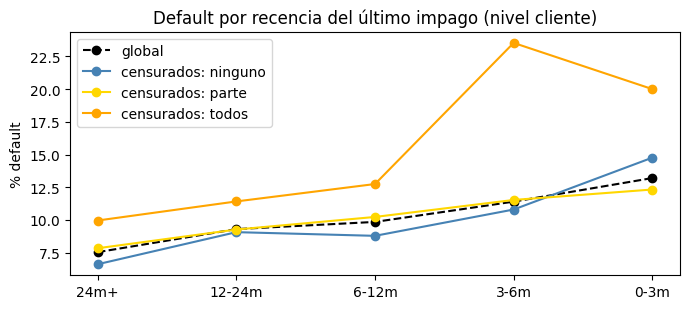

In [37]:
# recencia del último impago: lo que el snapshot de bureau no puede ver
ev.evaluar_continuas(["BB_MONTHS_SINCE_LAST_DPD"])
binsr = pd.cut(df["BB_MONTHS_SINCE_LAST_DPD"], [-97, -24, -12, -6, -3, 1],
               labels=["24m+", "12-24m", "6-12m", "3-6m", "0-3m"])
tabr = df.groupby(binsr, observed=True)["TARGET"].agg(n="size", tasa="mean")
tabr["tasa"] = (tabr["tasa"] * 100).round(2)
display(tabr)

# ¿riesgo o efecto de la ventana? mismo corte por proporción de créditos que dejan de reportarse
censb = pd.cut(df["BB_CENSORED_RATIO"], [-0.01, 0.001, 0.999, 1.01], labels=["ninguno", "parte", "todos"])
tabc = df[has].groupby(censb[has], observed=True)["TARGET"].agg(n="size", tasa="mean")
tabc["tasa"] = (tabc["tasa"] * 100).round(2)
display(tabc)
estr = df[any_dpd].pivot_table(index=binsr[any_dpd], columns=censb[any_dpd], values="TARGET",
                               aggfunc=["size", "mean"], observed=True)
display(estr.round(4))

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(tabr.index.astype(str), tabr["tasa"], "o--", color="black", label="global")
for cens, color in [("ninguno", COLOR_NODEF), ("parte", "gold"), ("todos", "orange")]:
    ax.plot(tabr.index.astype(str), estr[("mean", cens)] * 100, "o-", color=color, label=f"censurados: {cens}")
ax.set(title="Default por recencia del último impago (nivel cliente)", ylabel="% default")
ax.legend(); plt.tight_layout(); plt.show()

In [38]:
# trayectoria: el peor recorrido entre sus créditos, solo con las dos mitades de la ventana reportadas
prioridad = {"sin mora": 0, "mejora": 1, "empeora": 2, "estable": 3}
tr = tray.loc[~tray["ciega"]].join(map_bc.set_index("SK_ID_BUREAU"))
peor = tr["trayectoria"].map(prioridad).groupby(tr["SK_ID_CURR"]).max()
df["BB_TRAJECTORY"] = df["SK_ID_CURR"].map(peor).map({v: k for k, v in prioridad.items()})
pop_tr = df["BB_TRAJECTORY"].notna().values

tabt = df.groupby("BB_TRAJECTORY", observed=True)["TARGET"].agg(n="size", tasa="mean")
tabt = tabt.reindex(["sin mora", "mejora", "empeora", "estable"])
tabt["tasa"] = (tabt["tasa"] * 100).round(2)
display(tabt)
print(f"clientes con trayectoria evaluable: {int(pop_tr.sum()):,}")

ev.evaluar_flags([("BB_PERSISTENT_DPD_FLAG", df["BB_TRAJECTORY"].eq("estable").values, pop_tr, "trayectoria evaluable"),
                  ("BB_WORSENING_DPD_FLAG", df["BB_TRAJECTORY"].eq("empeora").values, pop_tr, "trayectoria evaluable"),
                  ("BB_RECOVERED_DPD_FLAG", df["BB_TRAJECTORY"].eq("mejora").values, pop_tr, "trayectoria evaluable")])

# ¿la persistencia es señal propia o mora reciente disfrazada?
rec = df["BB_RECENT_DPD_FLAG"].fillna(0).eq(1).values
cruce = df[pop_tr].pivot_table(index="BB_TRAJECTORY", columns=rec[pop_tr], values="TARGET",
                               aggfunc=["size", "mean"], observed=True)
display(cruce.reindex(["sin mora", "mejora", "empeora", "estable"]).round(4))

pers = df["BB_TRAJECTORY"].eq("estable").values
for etiqueta, estrato in [("con mora reciente", pop_tr & rec), ("sin mora reciente", pop_tr & ~rec)]:
    a, b = estrato & pers, estrato & ~pers
    print(f"{etiqueta}: persistente {target[a].mean() * 100:.2f}% (n={int(a.sum()):,}) vs resto "
          f"{target[b].mean() * 100:.2f}% (n={int(b.sum()):,}) | delta {(target[a].mean() - target[b].mean()) * 100:+.2f}pp")

,n,tasa
BB_TRAJECTORY,,
sin mora,45141,7.10
mejora,6098,8.72
empeora,9411,11.16
estable,6013,11.94


clientes con trayectoria evaluable: 66,663


Variable,Población,Tasa (1),Tasa (0),Delta,z-stat,p-valor
BB_PERSISTENT_DPD_FLAG,trayectoria evaluable,11.94% (n=6013),7.89% (n=60650),+4.05 pp,10.9,1.5617500477316458e-27
BB_WORSENING_DPD_FLAG,trayectoria evaluable,11.16% (n=9411),7.78% (n=57252),+3.37 pp,11.0,3.077191542107834e-28
BB_RECOVERED_DPD_FLAG,trayectoria evaluable,8.72% (n=6098),8.21% (n=60565),+0.51 pp,1.4,0.1666298415853591


size          mean        
               False True    False   True 
BB_TRAJECTORY                             
sin mora       44656   485  0.0707  0.1031
mejora          5154   944  0.0830  0.1102
empeora         3542  5869  0.0935  0.1225
estable         2189  3824  0.1051  0.1276

con mora reciente: persistente 12.76% (n=3,824) vs resto 11.96% (n=7,298) | delta +0.80pp
sin mora reciente: persistente 10.51% (n=2,189) vs resto 7.34% (n=53,352) | delta +3.17pp


In [39]:
# el conteo de créditos con histórico solo marca en su cola
ev.evaluar_flags([("BB_MANY_CREDITS_FLAG", df["BB_N_CREDITS_WBAL"].ge(22).values, has, "con histórico")])
ev.evaluar_continuas(["BB_N_CREDITS_WBAL", "BB_MONTHS_MAX", "BB_MONTHS_TOTAL"])

Variable,Población,Tasa (1),Tasa (0),Delta,z-stat,p-valor
BB_MANY_CREDITS_FLAG,con histórico,11.08% (n=749),8.12% (n=91482),+2.96 pp,3.0,0.0031479930378448223


Variable,Población,n,Rank-Biserial,p-valor,Mediana (0),Mediana (1)
BB_N_CREDITS_WBAL,no nulos (auto-cond.),92231,0.0058,0.3980821489127381,5.0,4.0
BB_MONTHS_MAX,no nulos (auto-cond.),92231,0.1502,1.7192923132680968e-103,42.0,33.0
BB_MONTHS_TOTAL,no nulos (auto-cond.),92231,0.1151,1.4357799188106676e-61,112.0,87.0


In [40]:
# ¿mide el histórico mensual la misma mora que bureau? concordancia crédito a crédito
b_over = ((bureau["AMT_CREDIT_MAX_OVERDUE"] > 0) | (bureau["AMT_CREDIT_SUM_OVERDUE"] > 0) |
          (bureau["CREDIT_DAY_OVERDUE"] > 0))
comp = pd.DataFrame({"bureau": b_over.set_axis(bureau["SK_ID_BUREAU"]).reindex(credf.index).fillna(False),
                     "mensual": flags["has_dpd"], "TARGET": credf["TARGET"]})
print(f"créditos con las dos fuentes: {len(comp):,} | acuerdo: {comp['bureau'].eq(comp['mensual']).mean() * 100:.2f}%")
grupos_c = {"ninguna": ~comp.bureau & ~comp.mensual, "solo bureau": comp.bureau & ~comp.mensual,
            "solo mensual": ~comp.bureau & comp.mensual, "ambas": comp.bureau & comp.mensual}
display(pd.DataFrame([{"fuente que marca": k, "créditos": int(m.sum()),
                       "% default": round(comp.loc[m, "TARGET"].mean() * 100, 2)} for k, m in grupos_c.items()]))

# unión de las dos fuentes a nivel cliente, contra cada una por separado
df["BUREAU_OVERDUE_UNION"] = df["SK_ID_CURR"].map(b_over.groupby(bureau["SK_ID_CURR"]).max()).fillna(0).astype("int8")
df["BB_OVERDUE_UNION"] = (df["BB_ANY_DPD_FLAG"].fillna(0).gt(0) | df["BUREAU_OVERDUE_UNION"].gt(0)).astype("int8")
tiene_bureau = df["SK_ID_CURR"].isin(bureau["SK_ID_CURR"]).values
ev.evaluar_flags([("BUREAU_OVERDUE_UNION", df["BUREAU_OVERDUE_UNION"].values, tiene_bureau, "con historial de bureau"),
                  ("BB_OVERDUE_UNION", df["BB_OVERDUE_UNION"].values, tiene_bureau, "con historial de bureau")])
A, B = df["BB_ANY_DPD_FLAG"].fillna(0).eq(1)[has], df["BUREAU_OVERDUE_UNION"].eq(1)[has]
print(f"mora mensual vs mora de bureau: V de Cramér {association(pd.crosstab(A, B), method='cramer', correction=True):.4f} | "
      f"Jaccard {int((A & B).sum()) / int((A | B).sum()):.4f} | solo mensual {int((A & ~B).sum()):,} | "
      f"solo bureau {int((B & ~A).sum()):,}")

# redundancia estructural con la profundidad de historial de bureau y solape con el score de buró
df["BUREAU_DAYS_CREDIT_MIN"] = df["SK_ID_CURR"].map(bureau.groupby("SK_ID_CURR")["DAYS_CREDIT"].min())
for c in ["BB_MONTHS_MAX", "BB_MONTHS_TOTAL", "BB_MONTHS_SINCE_LAST_DPD"]:
    s = df.loc[has, [c, "BUREAU_DAYS_CREDIT_MIN"]].dropna()
    print(f"{c} vs BUREAU_DAYS_CREDIT_MIN: r = {pearsonr(s[c], s['BUREAU_DAYS_CREDIT_MIN'])[0]:+.4f} (n={len(s):,})")

df["EXT_SOURCE_3"] = df["SK_ID_CURR"].map(train.set_index("SK_ID_CURR")["EXT_SOURCE_3"])
feats = ["BB_RECENT_DPD_FLAG", "BB_MONTHS_SINCE_LAST_DPD", "BB_ANY_DPD_FLAG", "BB_PCT_MONTHS_DPD",
         "BB_WRITEOFF_FLAG", "BB_MONTHS_MAX", "BB_N_CREDITS_WBAL"]
solape = df.loc[has, feats + ["EXT_SOURCE_3"]].corr()["EXT_SOURCE_3"].drop("EXT_SOURCE_3")
display(solape.round(4).sort_values(key=abs, ascending=False).to_frame("r con EXT_SOURCE_3"))

créditos con las dos fuentes: 523,515 | acuerdo: 85.59%


,fuente que marca,créditos,% default
0,ninguna,435381,7.86
1,solo bureau,20172,10.26
2,solo mensual,55281,10.09
3,ambas,12681,11.41


Variable,Población,Tasa (1),Tasa (0),Delta,z-stat,p-valor
BUREAU_OVERDUE_UNION,con historial de bureau,9.62% (n=72419),7.02% (n=191072),+2.60 pp,22.3,2.4066249705343855e-110
BB_OVERDUE_UNION,con historial de bureau,9.54% (n=88419),6.81% (n=175072),+2.73 pp,24.8,3.04967394447279e-135


mora mensual vs mora de bureau: V de Cramér 0.3945 | Jaccard 0.3889 | solo mensual 16,000 | solo bureau 7,653
BB_MONTHS_MAX vs BUREAU_DAYS_CREDIT_MIN: r = -0.7451 (n=92,231)
BB_MONTHS_TOTAL vs BUREAU_DAYS_CREDIT_MIN: r = -0.6041 (n=92,231)
BB_MONTHS_SINCE_LAST_DPD vs BUREAU_DAYS_CREDIT_MIN: r = +0.3231 (n=31,052)


,r con EXT_SOURCE_3
BB_MONTHS_SINCE_LAST_DPD,-0.3150
BB_RECENT_DPD_FLAG,-0.2808
BB_ANY_DPD_FLAG,-0.2351
BB_N_CREDITS_WBAL,-0.2124
BB_MONTHS_MAX,0.2041
BB_PCT_MONTHS_DPD,-0.1449
BB_WRITEOFF_FLAG,-0.0823


In [41]:
# el corte de 6 meses viene heredado: ¿lo sostiene la evidencia?
ev.evaluar_flags([(f"impago en los últimos {k} meses", df["BB_MONTHS_SINCE_LAST_DPD"].ge(-k).values, has,
                   "con histórico") for k in [3, 6, 12]])

# la recencia absoluta cuenta hasta la solicitud, pero un tercio de los créditos deja de reportarse antes
cf["_rel"] = cf["rec_dpd"] - cf["fin"]  # meses entre el último impago y el fin de la ventana del crédito
df["BB_MONTHS_SINCE_LAST_DPD_REL"] = df["SK_ID_CURR"].map(cf.groupby("SK_ID_CURR")["_rel"].max())
ev.evaluar_continuas(["BB_MONTHS_SINCE_LAST_DPD", "BB_MONTHS_SINCE_LAST_DPD_REL"])

par = df[["BB_MONTHS_SINCE_LAST_DPD", "BB_MONTHS_SINCE_LAST_DPD_REL"]].dropna()
print(f"las dos recencias entre sí: r = {pearsonr(par.iloc[:, 0], par.iloc[:, 1])[0]:.4f} (n={len(par):,})")
binrel = pd.cut(df["BB_MONTHS_SINCE_LAST_DPD_REL"], [-97, -24, -12, -6, -3, 1],
                labels=["24m+", "12-24m", "6-12m", "3-6m", "0-3m"])
tabrel = df.groupby(binrel, observed=True)["TARGET"].agg(n="size", tasa="mean")
tabrel["tasa"] = (tabrel["tasa"] * 100).round(2)
display(tabrel)

Variable,Población,Tasa (1),Tasa (0),Delta,z-stat,p-valor
impago en los últimos 3 meses,con histórico,12.9% (n=8611),7.65% (n=83620),+5.25 pp,17.0,1.6154953843710853e-64
impago en los últimos 6 meses,con histórico,12.42% (n=11602),7.53% (n=80629),+4.89 pp,18.0,1.3846285031535888e-72
impago en los últimos 12 meses,con histórico,11.71% (n=15889),7.4% (n=76342),+4.31 pp,18.1,4.168598337188559e-73


Variable,Población,n,Rank-Biserial,p-valor,Mediana (0),Mediana (1)
BB_MONTHS_SINCE_LAST_DPD,no nulos (auto-cond.),31052,0.1379,1.7047293850946652e-36,-12.0,-8.0
BB_MONTHS_SINCE_LAST_DPD_REL,no nulos (auto-cond.),31052,0.1584,1.153904538017228e-47,-8.0,-5.0


las dos recencias entre sí: r = 0.8229 (n=31,052)


,n,tasa
BB_MONTHS_SINCE_LAST_DPD_REL,,
24m+,7312,6.62
12-24m,5221,8.89
6-12m,5298,9.38
3-6m,4231,10.68
0-3m,8990,13.29


Variable,Población,Tasa (1),Tasa (0),Delta,z-stat,p-valor
BB_EXITS_IN_DPD_FLAG,con histórico,13.27% (n=4274),7.89% (n=87957),+5.37 pp,12.5,4.404519332579703e-36
BB_ALL_CLOSED_FLAG,con histórico,6.41% (n=18997),8.59% (n=73234),-2.18 pp,-9.8,1.2387022101761727e-22
BB_RECENT_DPD_FLAG_REL,con histórico,12.3% (n=14288),7.38% (n=77943),+4.92 pp,19.8,3.994974765198006e-87


,par,V de Cramér,Jaccard,n_1,n_2,comunes
0,BB_EXITS_IN_DPD_FLAG vs BB_RECENT_DPD_FLAG_REL,0.5148,0.2991,4274,14288,4274
1,BB_RECENT_DPD_FLAG vs BB_RECENT_DPD_FLAG_REL,0.8859,0.8120,11602,14288,11602


,grupo,n,% default
0,sin mora reciente,77943,7.38
1,reciente sin salir en mora,10014,11.89
2,sale en mora,4274,13.27


todo cerrado en el histórico vs en bureau: V de Cramér 0.5434 | Jaccard 0.4539
en las dos 5.96% (n=10,760) | solo en el histórico 7.00% (n=8,237) | solo en bureau 5.67% (n=4,710) | en ninguna 8.79% (n=68,524)


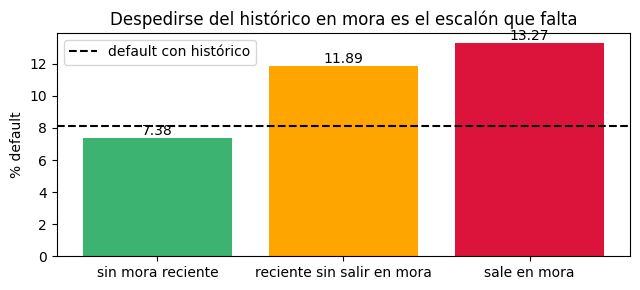

In [42]:
# ¿y si el crédito se despide del histórico estando en mora?
cf["ult"] = credf["ult"]
df["BB_EXITS_IN_DPD_FLAG"] = df["SK_ID_CURR"].map(
    cf.groupby("SK_ID_CURR")["ult"].apply(lambda x: x.isin(["1", "2", "3", "4", "5"]).any())) == True
df["BB_ALL_CLOSED_FLAG"] = df["SK_ID_CURR"].map(cf.groupby("SK_ID_CURR")["ult"].apply(lambda x: x.eq("C").all())) == True
df["BB_RECENT_DPD_FLAG_REL"] = df["BB_MONTHS_SINCE_LAST_DPD_REL"].ge(-6)  # el corte, sobre la recencia que sí se conserva

ev.evaluar_flags([(c, df[c].values, has, "con histórico") for c in
                  ["BB_EXITS_IN_DPD_FLAG", "BB_ALL_CLOSED_FLAG", "BB_RECENT_DPD_FLAG_REL"]])

# ¿features nuevas o cortes distintos de las que ya tengo?
fl2 = pd.DataFrame({c: df[c].values[has] for c in
                    ["BB_EXITS_IN_DPD_FLAG", "BB_RECENT_DPD_FLAG_REL", "BB_RECENT_DPD_FLAG"]})
fl2["BB_RECENT_DPD_FLAG"] = df["BB_RECENT_DPD_FLAG"].fillna(0).eq(1).values[has]
filas2 = []
for a, b in [("BB_EXITS_IN_DPD_FLAG", "BB_RECENT_DPD_FLAG_REL"), ("BB_RECENT_DPD_FLAG", "BB_RECENT_DPD_FLAG_REL")]:
    A, B = fl2[a], fl2[b]
    filas2.append({"par": f"{a} vs {b}",
                   "V de Cramér": round(association(pd.crosstab(A, B), method="cramer", correction=True), 4),
                   "Jaccard": round(int((A & B).sum()) / int((A | B).sum()), 4),
                   "n_1": int(A.sum()), "n_2": int(B.sum()), "comunes": int((A & B).sum())})
display(pd.DataFrame(filas2))

sale, rec_rel = fl2["BB_EXITS_IN_DPD_FLAG"], fl2["BB_RECENT_DPD_FLAG_REL"]
part = {"sin mora reciente": ~sale & ~rec_rel, "reciente sin salir en mora": ~sale & rec_rel, "sale en mora": sale}
tabsal = pd.DataFrame([{"grupo": k, "n": int(m.sum()), "% default": round(t_has[m.values].mean() * 100, 2)}
                       for k, m in part.items()])
display(tabsal)

# el cierre total, ¿lo aporta el histórico o ya lo decía bureau?
cerr_b = bureau.assign(c=bureau["CREDIT_ACTIVE"].astype(str).eq("Closed")).groupby("SK_ID_CURR")["c"].agg(["sum", "size"])
df["_bureau_todo_cerrado"] = df["SK_ID_CURR"].map(cerr_b["sum"].eq(cerr_b["size"])) == True
A, B = df["BB_ALL_CLOSED_FLAG"].values[has], df["_bureau_todo_cerrado"].values[has]
print(f"todo cerrado en el histórico vs en bureau: V de Cramér "
      f"{association(pd.crosstab(A, B), method='cramer', correction=True):.4f} | Jaccard {(A & B).sum() / (A | B).sum():.4f}")
print(" | ".join(f"{k} {t_has[m].mean() * 100:.2f}% (n={int(m.sum()):,})" for k, m in
                 {"en las dos": A & B, "solo en el histórico": A & ~B, "solo en bureau": ~A & B, "en ninguna": ~A & ~B}.items()))

fig, ax = plt.subplots(figsize=(6.5, 3))
barras = ax.bar(tabsal["grupo"], tabsal["% default"], color=["mediumseagreen", "orange", COLOR_DEF])
ax.bar_label(barras, fmt="%.2f")
ax.axhline(t_has.mean() * 100, color="black", ls="--", label="default con histórico")
ax.set(title="Despedirse del histórico en mora es el escalón que falta", ylabel="% default", xlabel="")
ax.legend(); plt.tight_layout(); plt.show()

Al subir del crédito al cliente la pregunta es cuánta de la señal medida a nivel crédito sobrevive, y la primera respuesta llega por donde no esperaba: la disponibilidad misma del histórico mensual no dice nada. Los 92.231 clientes que lo tienen dan 8,14% de default frente al 8,04% de los 215.280 que no, un +0,10pp con p=0,35. Al contrario que el historial en `bureau`, que por sí solo separaba 2,39pp, aquí quien decide si hay histórico es el buró y no el cliente, así que sirve para condicionar las mediciones y no para predecir. Y hace falta condicionarlas, porque el grupo que no tiene histórico no es equivalente al que lo tiene y no ha tenido mora: 8,04% frente a 7,22%, con los morosos en 9,96%.

Ese control mueve las cifras de forma desigual según la flag. La mora pasa de +2,10pp a **+2,74pp** al medirla solo entre quienes tienen histórico, y la mora reciente de +4,52pp a **+4,89pp**. El fallido apenas se mueve, de +2,96pp a +2,94pp, porque su grupo de referencia ya estaba dominado por clientes con histórico. Comparado con el nivel crédito la dilución es menor de lo que temía: la mora reciente pasa de +5,06pp a +4,89pp, y la mora genérica incluso **gana** al agregar, de +2,37pp a +2,74pp, porque basta un crédito tocado para marcar al cliente.

La recencia se confirma como la señal principal de la tabla. Su versión continua da rank-biserial 0,1379 sobre los 31.052 clientes con algún DPD, y el gradiente es monótono y ancho: 7,54% cuando el último DPD fue hace más de 24 meses, 9,30% entre 12 y 24, 9,85% entre 6 y 12, 11,40% entre 3 y 6 y **13,20% en los últimos 3 meses**. Antes de darlo por bueno había que descartar que fuese efecto de hasta cuándo se observa cada crédito, y no lo es: la censura por sí sola no discrimina (8,27% sin ningún crédito censurado, 8,10% con parte y 7,72% con todos) y el gradiente aguanta dentro de cada estrato con muestra suficiente, de 6,62% a 14,76% en los clientes sin censura y de 7,84% a 12,33% en los que la tienen parcial. Los clientes con todos sus créditos censurados quedan en 34 y 20 casos en los tramos recientes, así que sus tasas no son legibles.

El corte de 6 meses lo tenía heredado y conviene contrastarlo. Con DPD en los últimos 3 meses el delta sube a +5,25pp sobre 8.611 clientes, con 6 meses queda en +4,89pp sobre 11.602 y con 12 baja a +4,31pp sobre 15.889. No hay corte dominante, porque lo que se gana en delta se pierde en cobertura y los tres dan significancia casi idéntica (z de 17,0, 18,0 y 18,1). Conservo el corte de 6 meses como compromiso, pero la lectura de fondo es que la binaria simplifica un gradiente continuo y lo que debe entrar al modelo es la recencia por tramos.

La forma de contar esa recencia sí cambia el resultado. Medida en meses hasta la solicitud da 0,1379, y medida hasta el fin de la ventana de cada crédito sube a **0,1584**, un 15% más, con un gradiente más ancho que va de 6,62% a 13,29%. No son dos features, correlacionan 0,8229 y solo puede entrar una: entra la relativa. Tiene sentido de negocio, porque al no penalizar a los créditos que dejaron de observarse hace tiempo aísla al que salió del histórico estando en mora, que es el mismo perfil que llegaba al 23,60% de default.

Las tres flags de mora no son tres cosas distintas, pero tampoco una sola. La genérica y la reciente dan V de Cramér 0,5324, por encima del umbral de redundancia, y sin embargo la partición residual las salva: sin mora 7,22%, **mora antigua 8,49%** y mora reciente 12,42%. La parte antigua conserva 1,27pp propios sobre los limpios, de modo que el problema no es que sobre, es que está mal cortada: procede un corte de tres niveles y no una binaria que fusione al moroso de hace tres años con el de hace tres meses. El fallido sí es independiente (V de Cramér 0,2196), y también lo es de la reciente, con 0,1705, así que no es un caso extremo de mora reciente sino un eje aparte, y aporta 1,14pp por encima de la mora genérica, 11,02% frente al 9,88% de quien tuvo mora sin llegar a fallido.

Donde la evidencia me corrige es en la severidad. Esperaba tener que elegir entre severidad e intensidad por redundancia, porque a nivel crédito correlacionaban a 0,7882, y al agregar por cliente esa correlación baja a 0,6812, por debajo del umbral: ya no son el mismo eje. Pero la elección se resuelve por otro camino. La escala del peor estado alcanzado no es monótona (7,20%, 10,06%, 8,75%, 8,56%, 9,63% y 11,02%), todo el salto está en pasar de ningún DPD a tenerlo, y el test que decide lo remata: **dentro de los clientes que ya tienen mora, el peor estado alcanzado no discrimina nada**, con rank-biserial 0,0065 y p=0,40. Lo que informa es haber tenido mora y haber llegado a fallido, no el escalón intermedio. La severidad como escala se cae, no por redundante sino por vacía.

La intensidad es la única de las cuatro medidas de magnitud que aporta por encima de tener mora: 0,1035 con p=3,2e-21, y un gradiente limpio dentro de los morosos que va de 8,30% con hasta un 5% de meses en mora hasta **13,63% por encima del 50%**. El conteo de meses en mora (0,0367) y el de créditos afectados (0,0270) se quedan muy por detrás. Su denominador exige un mínimo, y ya tiene número: la señal pasa de 0,0981 sin exigir nada a 0,1040 desde 3 meses reportados, **0,1095 desde 6** y 0,1129 desde 12. Fijo el corte en 6, que mejora un 12% sobre no exigir mínimo y conserva 83.971 de 89.856 clientes. Aparte quedan 2.375 clientes (el 2,58% de los que tienen histórico) sin un solo mes con estado reportado en ninguno de sus créditos: van a valor ausente en severidad e intensidad, nunca a cero, porque confundir la falta de dato con la ausencia de mora es justo lo que diluye la señal que busco. Con un matiz de coherencia que conviene no esconder: esos mismos clientes sí quedan a cero en las flags de mora, no ausentes, que es justo lo que reprocho a la severidad. El efecto está medido y es nulo, +2,74pp frente al +2,76pp que da la misma flag sobre los que sí reportan, así que lo dejo como está, pero dicho.

La trayectoria, que es la pregunta que solo un histórico mensual puede responder, resulta ser feature propia. Sobre los 66.663 clientes cuyos créditos tienen las dos mitades de la ventana reportadas: sin mora 7,10%, quien mejora 8,72%, quien empeora 11,16% y **quien se mantiene en mora 11,94%**. La persistencia vuelve a pesar más que el deterioro, y aparece un matiz que a nivel crédito no se veía tan nítido: **recuperarse deja de ser señal**, con +0,51pp y p=0,17, o sea que el cliente que sale de la mora vuelve al riesgo de base. Lo importante es que no duplica la recencia. Cruzando ambas, la persistencia aporta **3,17pp entre los clientes sin mora reciente** (10,51% frente a 7,34%) y solo 0,80pp entre los que ya la tienen: lo que rescata es al moroso crónico cuyo último DPD no es reciente, precisamente el que la flag de recencia deja fuera. Dentro de los no recientes el orden se mantiene entero, 7,07%, 8,30%, 9,35% y 10,51%.

Hay una pregunta que el estado final de cada crédito deja servida y que no había hecho: no cuánto hace del último impago, sino si el crédito se despide del histórico estando en mora. A nivel cliente eso da **13,27% frente a 7,89%, +5,37pp** sobre 4.274 clientes, por encima incluso de la mora reciente. No es una feature independiente, porque los 4.274 están contenidos en los 14.288 con mora reciente, pero tampoco es la misma: la partición limpia da 7,38% sin nada, 11,89% con mora reciente que no acaba en mora y **13,27% cuando el crédito se despide impagado**. Es otra vez el patrón de la flag mal cortada, así que lo que procede es un nivel más dentro de la mora reciente y no una variable nueva al lado.

Su reverso parecía igual de prometedor y el contraste lo tumba. Que todos los créditos del cliente salgan cerrados da 6,41% frente a 8,59%, un -2,18pp protector sobre 18.997 clientes, mucha más cartera que cualquier flag de mora. Pero ese cierre ya lo reporta `bureau`, y comparadas dan V de Cramér 0,5434 por encima del umbral de redundancia. El desglose decide: cuando las dos fuentes coinciden en que está todo cerrado el riesgo es 5,96%, cuando solo lo dice `bureau` es 5,67%, y cuando solo lo dice el histórico mensual sube a 7,00%, mucho más cerca de la base. La versión útil de esa información es la de `bureau`, así que la descarto aquí en vez de duplicarla peor.

El contraste de las dos recencias obliga además a corregir la flag. La recencia que se conserva es la relativa al fin de ventana, pero la flag de mora reciente estaba recortada sobre la absoluta, que es justo la que se descarta. Cortada sobre la relativa rinde algo más y alcanza a más gente, **+4,92pp sobre 14.288 clientes** frente a +4,89pp sobre 11.602, con mejor significancia (z de 19,8 frente a 18,0). Entre las dos versiones la V de Cramér es 0,8859, así que entra una sola, y entra la relativa. Y conviene decir algo que la lista de arriba no dejaba claro: la flag y la recencia por tramos no son dos features complementarias sino dos codificaciones de la misma variable, con correlación 0,6629 entre ellas. Al modelo va una.

El número de créditos con histórico confirma lo que apuntaba su cola: como variable continua es ruido (0,0058, p=0,40) y como flag de 22 créditos o más rinde **+2,96pp** (11,08% frente a 8,12%), aunque solo alcanza a 749 clientes.

Queda lo que más me interesaba: cuánto de esto es nuevo. Comparando crédito a crédito la mora que reporta `bureau` con el DPD del histórico mensual sobre los 523.515 que tienen las dos fuentes, coinciden en el 85,59%, y **ninguna de las dos domina**: `bureau` marca en solitario 20.172 créditos con 10,26% de default y el histórico marca en solitario 55.281 con 10,09%, riesgos casi idénticos, frente al 11,41% cuando coinciden y al 7,86% cuando ninguna marca. La codificación correcta de la mora no es entonces elegir fuente sino sumarlas: a nivel cliente la unión da **+2,73pp sobre 88.419 clientes**, mejor que el +2,60pp sobre 72.419 de la mora de `bureau` sola, más delta y más cobertura a la vez. Y las dos fuentes se complementan de verdad, con V de Cramér 0,3945: el histórico mensual **rescata 16.000 clientes** que la mora agregada de `bureau` no marcaba, y `bureau` aporta otros 7.653 que el histórico no ve.

El cruce también me obliga a descartar la variable con más señal en crudo. `BB_MONTHS_MAX` da 0,1502 de rank-biserial, la más alta de todas, pero correlaciona −0,7451 con la profundidad del historial de `bureau`: mide longitud de historial, que ya está contada en otra tabla, y el descarte es firme porque no depende del TARGET. `BB_MONTHS_TOTAL` se queda en −0,6041, por debajo del umbral, así que su descarte deja de ser estructural y pasa a decidirse por capacidad predictiva más adelante. La recencia tampoco escapa del todo a ese eje: correlaciona +0,3231 con esa misma profundidad de historial, lejos del umbral de redundancia pero suficiente para recordar que un histórico largo permite que el último impago quede lejos por pura ventana de observación. Frente al score de buró, en cambio, no hay redundancia en ninguna: el máximo solape es 0,3150 en la recencia continua. Eso sí, marca dónde está el valor incremental, y no es donde está la señal más grande: el fallido (−0,0823) y la intensidad (−0,1449) son casi ortogonales al score, mientras que la recencia comparte con él en torno a 0,30 y tendrá que justificar su aportación por encima de él.

Y hay tres cortes que conviene marcar como lo que son. El denominador mínimo de 6 meses, el corte de 6 meses de la mora reciente y el de 22 créditos de la cola no son constantes del dominio: los he elegido comparando su rendimiento contra la tasa de default sobre el conjunto completo. Que los descartes por señal sean provisionales ya lo digo, pero estos parámetros lo son igual, y hay que refijarlos sobre el conjunto de entrenamiento antes de que viajen al pipeline, o el modelo hereda tres decisiones tomadas con el objetivo a la vista.

Conviene también dimensionar sobre qué cartera se aplica todo esto. El histórico mensual no existe para el **70,01%** de los clientes y la recencia no existe para el **89,90%**, porque a los que no tienen histórico se suman los que lo tienen y nunca entraron en mora. Con esa proporción de ausencia, cualquier tramificación tiene que llevar la ausencia como categoría propia y no como un valor, que es lo que haría un binning ingenuo, y conviene no confundir un delta grande con un impacto grande de cartera.

Tres apuntes para quien recoja esto. Ninguna feature mira al futuro, porque todos los meses del histórico son anteriores a la solicitud; la única salvedad de medición es la que ya declaro, que las tasas están calculadas sobre el conjunto completo. La recencia no existe para el 66% de los clientes con histórico y la trayectoria para el 28%, y en ambos casos esa ausencia significa que nunca hubo mora, no que se desconozca, así que entran como tramo propio y no imputadas. Y conviene dimensionar el alcance: la mora reciente marca a 11.602 clientes, el 3,8% del conjunto, o sea señal fuerte sobre poca cartera.

En resumen, lo que entra es el núcleo de mora reciente (`BB_RECENT_DPD_FLAG` y la recencia continua medida hasta el fin de la ventana de cada crédito), la mora en tres niveles en vez de binaria, el fallido, la intensidad con denominador mínimo de 6 meses, la trayectoria como persistencia, la unión de mora con `bureau` y la flag de cola del conteo de créditos. Lo que sale es la severidad como escala, el conteo de créditos como continua, la longitud de histórico, la recuperación y la recencia contada hasta la solicitud, que pierde contra su versión relativa. Y conviene distinguir por qué sale cada cosa: el descarte de la longitud de histórico es estructural y por tanto firme, mientras que todos los que se apoyan en la tasa de default están medidos sobre el train completo y habrá que reconfirmarlos sobre el conjunto de entrenamiento antes de dar ninguno por definitivo.

### 11. Conclusiones y features candidatas

In [43]:
# ranking consolidado: una decisión por feature, con la población en la que se midió
ESTADO = {
    "BB_RECENT_DPD_FLAG_REL": "conservar (mora reciente, cortada sobre la recencia relativa)",
    "BB_RECENT_DPD_FLAG": "descartar (cortada sobre la recencia absoluta, que también se descarta)",
    "BB_EXITS_IN_DPD_FLAG": "conservar (sale del histórico en mora)",
    "BB_ALL_CLOSED_FLAG": "descartar (redundante con el cierre que reporta bureau)",
    "BB_MONTHS_SINCE_LAST_DPD_REL": "conservar (recencia, en tramos)",
    "BB_OVERDUE_UNION": "conservar (codificación de mora)",
    "BB_ANY_DPD_FLAG": "conservar (en tres niveles)",
    "BB_WRITEOFF_FLAG": "conservar (fallido)",
    "BB_PCT_MONTHS_DPD": "conservar (denominador mínimo de 6)",
    "BB_PERSISTENT_DPD_FLAG": "conservar (persistencia)",
    "BB_WORSENING_DPD_FLAG": "conservar (deterioro)",
    "BB_MANY_CREDITS_FLAG": "IV (no pasa Bonferroni)",
    "BB_DPD_MONTHS_COUNT": "IV (secundaria)",
    "BB_CREDITS_WITH_DPD_COUNT": "IV (secundaria)",
    "BB_MONTHS_TOTAL": "IV (descarte ya no estructural)",
    "BB_STATUS_WORST": "descartar (vacía dentro de morosos)",
    "BB_STATUS_WORST > 0": "descartar (duplica BB_ANY_DPD_FLAG)",
    "BB_MONTHS_SINCE_LAST_DPD": "descartar (redundante con la relativa)",
    "BB_MONTHS_MAX": "descartar (redundancia con bureau, firme)",
    "BB_N_CREDITS_WBAL": "descartar (ruido como continua)",
    "BB_RECOVERED_DPD_FLAG": "descartar (sin señal)",
    "HAS_BUREAU_BALANCE": "control de composición",
    "BUREAU_OVERDUE_UNION": "referencia (feature de bureau)",
}
barrido = [f["feature"] for f in ev.fb_flags if f["feature"].startswith("impago en los últimos")]

n_feat = len(ev.fb_flags) + len(ev.fb_cont)          # familia válida: una decisión por feature
alpha = 0.05 / n_feat
alpha_consv = 0.05 / len(ev.fb_comparisons)          # todas las emitidas, referencia conservadora
print(f"features medidas: {n_feat} (de las cuales {len(barrido)} son el barrido del corte de recencia, "
      f"la misma feature con distinto umbral) | comparaciones emitidas: {len(ev.fb_comparisons)}")
print(f"Bonferroni: alpha = {alpha:.5f} (familia válida) | {alpha_consv:.5f} (conservador)")


def consolidar(acumulador):
    """tabla de decisión: efecto, significancia tras Bonferroni y estado, sin las filas del barrido."""
    d = pd.DataFrame(acumulador).query("feature not in @barrido").copy()
    d["sig"] = d["p"] < alpha
    d["estado"] = d["feature"].map(ESTADO)
    assert d["estado"].notna().all(), f"features sin estado: {d.loc[d.estado.isna(), 'feature'].tolist()}"
    return d.sort_values("efecto", key=abs, ascending=False)


rank_flags, rank_cont = consolidar(ev.fb_flags), consolidar(ev.fb_cont)
display(rank_flags.style.hide(axis="index").format({"efecto": "{:+.2f} pp", "p": "{:.2e}"}))
display(rank_cont.style.hide(axis="index").format({"efecto": "{:.4f}", "p": "{:.2e}"}))
no_pasan = pd.concat([rank_flags, rank_cont]).query("not sig")["feature"].tolist()
print(f"no superan Bonferroni: {no_pasan}")

features medidas: 26 (de las cuales 3 son el barrido del corte de recencia, la misma feature con distinto umbral) | comparaciones emitidas: 31
Bonferroni: alpha = 0.00192 (familia válida) | 0.00161 (conservador)


feature,tipo,poblacion,efecto,p,n_pos,sig,estado
BB_EXITS_IN_DPD_FLAG,flag,con histórico,+5.37 pp,4.40e-36,4274,True,conservar (sale del histórico en mora)
BB_RECENT_DPD_FLAG_REL,flag,con histórico,+4.92 pp,3.99e-87,14288,True,"conservar (mora reciente, cortada sobre la recencia relativa)"
BB_RECENT_DPD_FLAG,flag,con histórico,+4.89 pp,1.38e-72,11602,True,"descartar (cortada sobre la recencia absoluta, que también se descarta)"
BB_PERSISTENT_DPD_FLAG,flag,trayectoria evaluable,+4.05 pp,1.56e-27,6013,True,conservar (persistencia)
BB_WORSENING_DPD_FLAG,flag,trayectoria evaluable,+3.37 pp,3.08e-28,9411,True,conservar (deterioro)
BB_MANY_CREDITS_FLAG,flag,con histórico,+2.96 pp,3.15e-03,749,False,IV (no pasa Bonferroni)
BB_WRITEOFF_FLAG,flag,con histórico,+2.94 pp,5.92e-07,2206,True,conservar (fallido)
BB_STATUS_WORST > 0,flag,con estado reportado,+2.76 pp,8.74e-47,31052,True,descartar (duplica BB_ANY_DPD_FLAG)
BB_ANY_DPD_FLAG,flag,con histórico,+2.74 pp,9.49e-47,31052,True,conservar (en tres niveles)
BB_OVERDUE_UNION,flag,con historial de bureau,+2.73 pp,3.05e-135,88419,True,conservar (codificación de mora)


feature,tipo,poblacion,efecto,p,n_pos,sig,estado
BB_MONTHS_SINCE_LAST_DPD_REL,continua,no nulos (auto-cond.),0.1584,1.15e-47,31052,True,"conservar (recencia, en tramos)"
BB_MONTHS_MAX,continua,no nulos (auto-cond.),0.1502,1.72e-103,92231,True,"descartar (redundancia con bureau, firme)"
BB_MONTHS_SINCE_LAST_DPD,continua,no nulos (auto-cond.),0.1379,1.70e-36,31052,True,descartar (redundante con la relativa)
BB_MONTHS_TOTAL,continua,no nulos (auto-cond.),0.1151,1.44e-61,92231,True,IV (descarte ya no estructural)
BB_PCT_MONTHS_DPD,continua,no nulos (auto-cond.),0.1095,8.24e-67,83971,True,conservar (denominador mínimo de 6)
BB_DPD_MONTHS_COUNT,continua,clientes con mora,0.0367,6.80e-04,31052,True,IV (secundaria)
BB_CREDITS_WITH_DPD_COUNT,continua,clientes con mora,0.0270,8.06e-03,31052,False,IV (secundaria)
BB_STATUS_WORST,continua,clientes con mora,0.0065,4.01e-01,31052,False,descartar (vacía dentro de morosos)
BB_N_CREDITS_WBAL,continua,no nulos (auto-cond.),0.0058,3.98e-01,92231,False,descartar (ruido como continua)


no superan Bonferroni: ['BB_MANY_CREDITS_FLAG', 'BB_RECOVERED_DPD_FLAG', 'HAS_BUREAU_BALANCE', 'BB_CREDITS_WITH_DPD_COUNT', 'BB_STATUS_WORST', 'BB_N_CREDITS_WBAL']


In [44]:
# la receta se exporta desde el ranking, así que no puede desincronizarse de las decisiones de arriba
# lleva la decisión y su justificación; cómo se construye cada feature es cosa del código de FE
import yaml
import src

receta = {
    "tabla": "bureau_balance",
    "nivel": "SK_ID_CURR (doble agregación desde SK_ID_BUREAU vía bureau)",
    "nota": ("cobertura del 29,99% de train, completa por cliente en el 99,78% de los casos. "
             "Cruces con TARGET sobre train completo: los descartes por señal son provisionales y "
             "se reconfirman sobre el split; los de redundancia estructural son firmes. Medir IV "
             "incremental sobre EXT_SOURCE_3 antes de fijar la lista."),
    "features": {},
}
for d in (rank_flags, rank_cont):
    for _, r in d.iterrows():
        receta["features"][r["feature"]] = {
            "tipo": r["tipo"],
            "poblacion_medicion": r["poblacion"],
            "efecto": round(float(r["efecto"]), 4),
            "estado": r["estado"],
        }
receta["features"]["BB_CENSORED_RATIO"] = {
    "tipo": "control", "poblacion_medicion": "con histórico", "efecto": None,
    "estado": "control (desplaza la recencia, no es predictor)"}

out = Path(src.__file__).resolve().parents[1] / "config" / "bureau_balance_features.yaml"
out.write_text(yaml.safe_dump(receta, allow_unicode=True, sort_keys=False))
print(f"receta escrita en {out.relative_to(Path.cwd().parent)} con {len(receta['features'])} features")

receta escrita en config/bureau_balance_features.yaml con 24 features


El histórico mensual aporta una dimensión que el resto de la información de buró no tiene, que es **cuándo** ocurrió la mora, y ahí está toda su razón de estar. Comparado crédito a crédito con la mora que ya reportaba `bureau` coincide en el 85,59% de los casos, pero los desacuerdos no son ruido: cada fuente marca en solitario un grupo con riesgo equivalente al de los que ambas señalan. A nivel cliente el histórico rescata 16.000 clientes con DPD que la mora agregada no marcaba, y `bureau` aporta otros 7.653 que el histórico no ve. Por eso codifico la mora como la unión de las dos, que rinde +2,73pp sobre 88.419 clientes, más delta y más cobertura que cualquiera por separado.

Con las 26 mediciones que forman la familia, de las cuales tres son el corte de recencia probado a distintos umbrales, el umbral de Bonferroni queda en 0,00192 y seis no lo superan. Tres eran descartes esperados: la presencia de histórico (+0,10pp, p=0,35), el conteo de créditos como continua (0,0058, p=0,40) y la recuperación (+0,51pp, p=0,17), que no es un fallo de medición sino el hallazgo de que quien sale de la mora vuelve al riesgo de base. Otras dos caen medidas dentro de los clientes que ya tienen mora, que es la población donde se decide su suerte, y confirman ahí lo que ya decía su efecto: el peor estado alcanzado (0,0065, p=0,40) y el conteo de créditos afectados (0,0270, p=0,0081). La sexta me obliga a bajar de categoría la flag de cola del conteo: +2,96pp parece atractivo, pero sobre 749 clientes el p=0,0031 no aguanta la corrección, así que la dejo para evaluar por capacidad predictiva y no entra por derecho propio.

Lo que conservo, con la codificación que exige cada una:

- La mora reciente (+4,92pp sobre 14.288 clientes), acompañada de la recencia continua **medida hasta el fin de la ventana de cada crédito** y repartida en tramos, no como valor continuo directo.
- Salir del histórico en mora (+5,37pp), como un nivel más dentro de la mora reciente y no como flag suelta: sin mora reciente 7,38%, reciente sin salir en mora 11,89% y sale en mora 13,27%.
- La mora en tres niveles (sin mora, antigua y reciente) en lugar de la binaria, que fusiona dos poblaciones separadas por casi 4pp.
- El fallido como flag propia (+2,94pp), que absorbe cualquier corte de gravedad intermedia.
- La intensidad, meses en mora sobre meses reportados, con un mínimo de 6 meses reportados y valor ausente por debajo.
- La persistencia y el deterioro (+4,05pp y +3,37pp), definidos solo sobre créditos con las dos mitades de la ventana reportadas.
- La unión de mora con `bureau` como codificación preferente frente a cualquiera de las dos fuentes sola.

Los descartes prefiero separarlos por grado de firmeza, porque no todos valen lo mismo. Firme y por estructura: la longitud del histórico, que con una correlación de −0,7451 mide lo mismo que la profundidad de historial que ya aporta `bureau`, y eso no depende del objetivo. Firme y por codificación: la recencia contada hasta la solicitud, que pierde contra su versión relativa con una correlación de 0,8229 entre ambas, y la flag derivada del peor estado, que duplica a la de mora. Provisionales, por medirse contra la tasa de default del conjunto completo: la severidad como escala, el conteo de créditos como continua y la recuperación, que reconfirmaré sobre el conjunto de entrenamiento antes de eliminarlos de verdad. Conservar de más es barato, eliminar mirando toda la etiqueta no.

Hay 3 cosas a tener en cuenta. La primera es de alcance: solo el 29,99% de los clientes tiene histórico mensual y la feature principal marca a 14.288, el 4,65% del conjunto, así que es señal fuerte sobre poca cartera y no puede sostener sola un modelo. La segunda es de solape: nada aquí supera el umbral de redundancia frente al score de buró de la solicitud, pero la recencia comparte con él alrededor de 0,30 y tendrá que demostrarme aportación por encima de ese score, mientras que el fallido y la intensidad son casi ortogonales y ahí está el valor más limpio. Por ultimo, es de medición: he calculado todas las tasas sobre el conjunto completo, así que la lista final la fijo después, sobre el conjunto de entrenamiento.

El perfil de deudor con mora se caracteriza con 2 nuevas conclusiones: la mora reciente pesa más que la grave, y dentro de la reciente el subgrupo duro es el moroso persistente, no el que empeora de forma puntual.